# Introducción y objetivo del taller #3:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhonattanreales21/nlp_icesi/blob/main/unidad_3/Cano_Reales_nlp_with_transformers_&_LSTM.ipynb)

**Taller de NLP para clasificación de texto: Transformers VS LSTM**

Integrantes:
- Andres Cano
- Jhonattan Reales

Para este notebook/Taller implementaremos un clasificador de noticias (4 categorias) del dataset ag_news en inglés.  
En el taller anterior se implementó solo un modelo basado en LSTM para llevar a cabo la tarea de clasificación de texto. Para este taller, se implementará un modelo basado en Transformers utilizando módulos definidos de PyTorch y se comparará su desempeño frente al modelo recurrente. Además, se llevará a cabo un analisis sencillo de tuneo de hiperparametros para el modelo Transformer, enfocado en encontrar mejoras en la tarea de clasificación de nuestro dataset.

A lo largo de este notebook llevaremos a cabo los siguientes pasos:
- Revisaremos y prepararemos el dataset, efectuando pasos de exploración de datos y de resultados cuando corresponda.
- Definiremos las arquitecturas base de ambos modelos (LSTM & Transformers) y sus implicaciones.
- Entrenaremos, evaluaremos y compararemos el desempeño de los modelos base propuestos.
- Desarrollaremos un tuneo de hiperparametros sencillo del modelo Transformer, en busqueda de posibles configuraciones que mejoren el desempeño de nuestras clasificaciones.
- Implementaremos el mejor modelo clasificador tipo Transformers en un conjunto de noticias que el modelo no haya visto con anterioridad.

En todas las secciones nombradas anteriormente, realizaremos un analisis de lo observado y dejaremos plasmados nuestros hallazgos, dudas y comemntarios en secciones con el titulo "**Nota:** "

PD: Es muy recomendable leer la sección final del notebook (conclusiones) antes de ir sección por sección, consideremos que esto puede ayudar a "no perderse" tanto a lo largo del taller. 


# **Paquetes y Semilla**

In [2]:
import pkg_resources
import warnings
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
import random
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns
import time

import re
import math
from collections import Counter

from tqdm.auto import tqdm

In [3]:
# Usar GPU si existe
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

warnings.filterwarnings("ignore")

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = "google-colab" in installed_packages

SEED = 198

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Hace que operaciones CUDA sean deterministas (más reproducible, un poco más lento)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed fijada en:", SEED)

Device: cuda
Seed fijada en: 198


# 1. Lectura de datos (AG News)

Para el desarrollo de este taller se utilizó el dataset **AG News**, un conjunto de datos ampliamente empleado en tareas de clasificación de texto en inglés. Este dataset está compuesto por noticias cortas provenientes de distintas fuentes periodísticas y organizadas en **cuatro categorías temáticas**: **World, Sports, Business** y **Sci/Tech**. Cada ejemplo contiene principalmente un fragmento de texto noticioso y una etiqueta que indica la categoría a la que pertenece.

AG News es un dataset adecuado para experimentos de clasificación multiclase porque presenta un volumen suficiente de ejemplos para entrenamiento y categorías con diferencias semánticas reconocibles, aunque no siempre totalmente separables. Además, AG News resulta especialmente conveniente en un contexto académico porque permite entrenar modelos en tiempos razonables

El propósito de utilizar este dataset en el taller es contar con un problema de **clasificación supervisada de texto** que permita comparar arquitecturas de procesamiento de lenguaje natural vistas en clase.


In [4]:
from datasets import load_dataset

ds = load_dataset("ag_news")
print(ds)

print("\nEjemplo train[0]:")
print(ds["train"][0])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Ejemplo train[0]:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


# 2. EDA
Procedemos a realizar un analisis exploratorio basico de las noticias y los labels de estas, con la finalidad de hacernos una idea de las particularidades de nuestro dataset y la posible necesidad de realizar pre-procesamientos.

## Distribucion de Clases

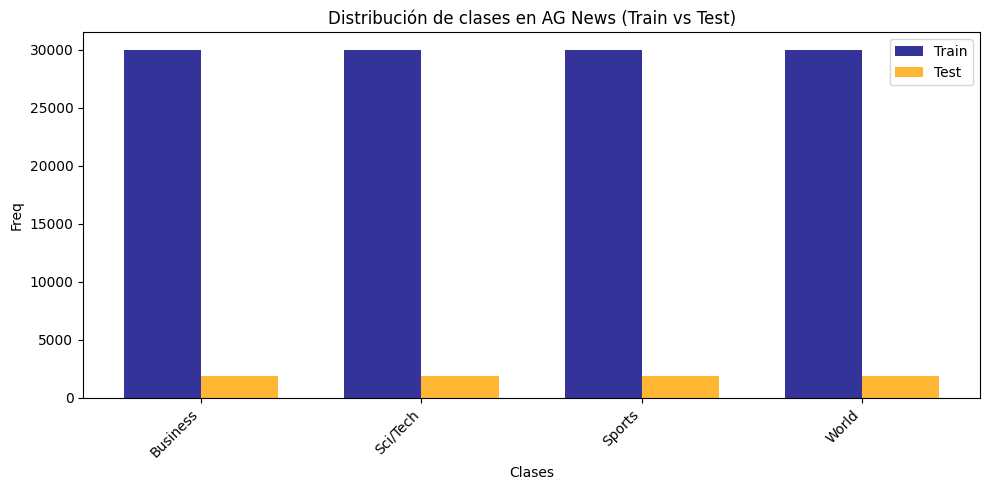

In [5]:
# Distribucion de clases en TRAIN y TEST
label_counts_train = Counter(ds["train"]["label"])
label_counts_test = Counter(ds["test"]["label"])

label_names = ds["train"].features["label"].names

# Conteo por nombre para train y test
counts_by_name_train = {label_names[k]: v for k, v in label_counts_train.items()}
counts_by_name_test = {label_names[k]: v for k, v in label_counts_test.items()}

# Preparamos datos para graficar
names = list(counts_by_name_train.keys())
counts_train = [counts_by_name_train[n] for n in names]
counts_test = [counts_by_name_test[n] for n in names]

# Graficamos la distribución de clases en train y test
x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, counts_train, width, label="Train", color="navy", alpha=0.8)
plt.bar(x + width / 2, counts_test, width, label="Test", color="orange", alpha=0.8)
plt.xlabel("Clases")
plt.ylabel("Freq")
plt.title("Distribución de clases en AG News (Train vs Test)")
plt.xticks(x, names, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

**Notas:**  
- Podemos observar que el dataset tanto de train como test, presentan una distribución de clases muy pareja, lo que en cierta medida disminuye la probabilidad de tener inconvenientes de desbalance a la hora de realizar la predicción de los labels de las noticias en el test set (predicción multiclase).

## Longitud de secuencias

- Este analisis nos puede ayudar a definir la posible longitud de las secuencias para el entrenamiento de los modelos.
- En este caso estamos utilizando un tokenizador sencillo para el EDA, pero para el modelo utilizaremos un tokenizador mas moderno lo cual posiblemente extienda el numero de tokens por secuencia.

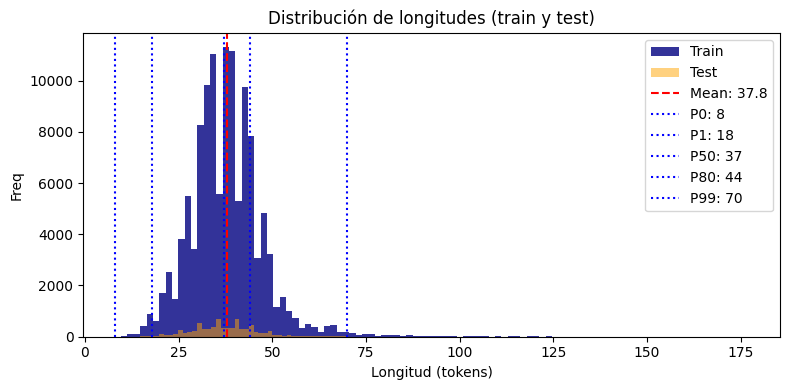

In [6]:
# Función simple de tokenización (solo para análisis de longitud, no para el modelo)
def simple_word_tokenizer(text: str):
    return text.lower().split()


# Analizamos la distribución de longitudes (en tokens) del texto
lengths_train = np.array([len(simple_word_tokenizer(t)) for t in ds["train"]["text"]])
lengths_test = np.array([len(simple_word_tokenizer(t)) for t in ds["test"]["text"]])

# Graficamos la distribución de longitudes y marcamos percentiles clave
percentiles = [0, 1, 50, 80, 99]
pvals_train = [int(np.percentile(lengths_train, p)) for p in percentiles]

plt.figure(figsize=(8, 4))
plt.hist(lengths_train, bins=100, color="navy", alpha=0.8, label="Train")
plt.hist(lengths_test, bins=100, color="orange", alpha=0.5, label="Test")
plt.axvline(
    lengths_train.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {lengths_train.mean():.1f}",
)
for p, val in zip(percentiles, pvals_train):
    plt.axvline(val, color="blue", linestyle=":", label=f"P{p}: {val}")
plt.xlabel("Longitud (tokens)")
plt.ylabel("Freq")
plt.title("Distribución de longitudes (train y test)")
plt.legend()
plt.tight_layout()
plt.show()

### Longitud de palabras por label y conjunto de datos

En este punto podemos analizar la heterogeneidad de la distribución de palabras por secuencia, por cada uno de los labels del dataset.

In [7]:
# Percentiles de longitud de tokens por clase (label) en TRAIN y TEST

percentiles_by_class = [1, 5, 25, 50, 75, 95, 99]

for split in ["train", "test"]:
    print(f"\n{'='*70}\nSplit: {split.upper()}\n{'='*70}")

    texts = ds[split]["text"]
    labels = ds[split]["label"]

    for class_id, class_name in enumerate(label_names):
        # Obtenemos las longitudes de tokens para los textos por cada clase
        class_lengths = np.array(
            [
                len(simple_word_tokenizer(t))
                for t, y in zip(texts, labels)
                if y == class_id
            ]
        )

        # Calculamos percentiles para cada clase
        pvals = np.percentile(class_lengths, percentiles_by_class)
        pvals_str = " | ".join(
            [f"P{p:>2}: {int(v):>3}" for p, v in zip(percentiles_by_class, pvals)]
        )

        print(
            f"{class_name:10s} -> "
            f"n={len(class_lengths):5d} | "
            f"mean={class_lengths.mean():6.2f} | "
            f"min={class_lengths.min():3d} | max={class_lengths.max():3d} | "
            f"{pvals_str}"
        )


Split: TRAIN
World      -> n=30000 | mean= 38.88 | min= 11 | max=145 | P 1:  19 | P 5:  23 | P25:  33 | P50:  39 | P75:  44 | P95:  55 | P99:  75
Sports     -> n=30000 | mean= 37.77 | min=  8 | max=151 | P 1:  21 | P 5:  26 | P25:  32 | P50:  37 | P75:  42 | P95:  52 | P99:  66
Business   -> n=30000 | mean= 37.54 | min=  8 | max=134 | P 1:  18 | P 5:  25 | P25:  32 | P50:  37 | P75:  42 | P95:  50 | P99:  58
Sci/Tech   -> n=30000 | mean= 37.19 | min=  8 | max=177 | P 1:  16 | P 5:  20 | P25:  30 | P50:  36 | P75:  42 | P95:  56 | P99:  84

Split: TEST
World      -> n= 1900 | mean= 38.55 | min= 15 | max=106 | P 1:  18 | P 5:  22 | P25:  32 | P50:  39 | P75:  44 | P95:  53 | P99:  71
Sports     -> n= 1900 | mean= 37.57 | min= 17 | max= 90 | P 1:  21 | P 5:  26 | P25:  32 | P50:  37 | P75:  42 | P95:  51 | P99:  66
Business   -> n= 1900 | mean= 37.63 | min= 14 | max=126 | P 1:  18 | P 5:  26 | P25:  33 | P50:  37 | P75:  42 | P95:  50 | P99:  57
Sci/Tech   -> n= 1900 | mean= 37.15 | min=

**Notas:**  
- La longitud de las palabras por secuencia es variable, tanto aa nivel general como separado por clases. Existen noticias con muy pocas palabras, incluso por debajo de 10, en contraste con noticias de mas de 100 palabras.
- Si observamos la longitud de las secuencias dividido por Train y Test, notamos que la distribución es ciertamente similar, con la diferencia de que en el conjunto de Test las noticias tienen menos variablidad y noticias con longitudes extremas (minimos y maximos).

El tema de la variabilidad en las secuencias por documento, nos lleva a la necesidad de:
- Restringir la longitud de las secuencias por documento (ej: a 100 tokens).
- Hacer clipping para los documentos que excedan el limite que estableceremos.
- Utilizar padding para rellenar las secuencias que nos hacen falta en algunos documentos.

## Nubes de palabras

Generamos nubes de palabras por cada clase para obtener una comprensión visual rápida del vocabulario más frecuente en cada tipo de noticia. Esta visualización nos permite generar intuición sobre qué palabras los modelos podrían aprender a asociar con cada clase. Esta exploración visual complementa el análisis cuantitativo previo y nos ayuda a anticipar posibles desafíos en la tarea de clasificación.

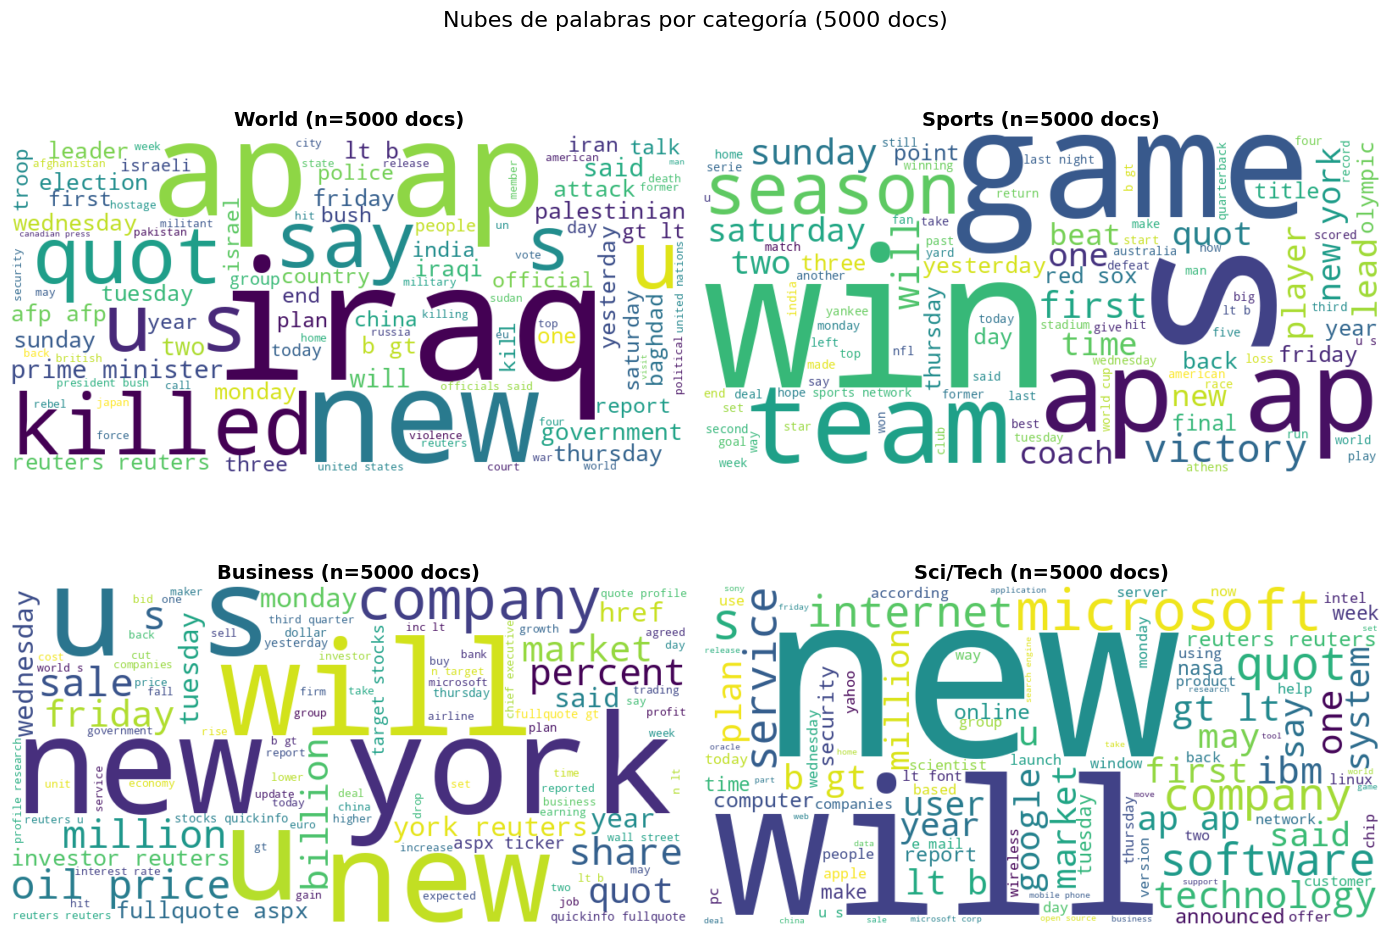

In [8]:
## Nube de palabras por clase

# Número máximo de documentos por clase para la nube de palabras
max_docs_per_class = 5000

# Crear figura con subplots para cada clase
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Para cada clase, generar nube de palabras
class_names = ds["train"].features["label"].names
for class_idx, class_name in enumerate(class_names):
    # Filtrar documentos de esta clase
    class_texts = [
        text
        for text, label in zip(ds["train"]["text"], ds["train"]["label"])
        if label == class_idx
    ]

    # Limitar a max_docs_per_class documentos (escogiendo al azar)
    if len(class_texts) > max_docs_per_class:
        class_texts = random.sample(class_texts, max_docs_per_class)

    # Concatenar todos los textos de la clase
    combined_text = " ".join(class_texts)

    # Tokenizador simple
    tokens = simple_word_tokenizer(combined_text)
    clean_text = " ".join(tokens)

    # Generar nube de palabras
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="viridis",
        max_words=100,
        relative_scaling=0.5,
        min_font_size=10,
    ).generate(clean_text)

    # Mostrar en el subplot correspondiente
    axes[class_idx].imshow(wordcloud, interpolation="bilinear")
    axes[class_idx].axis("off")
    axes[class_idx].set_title(
        f"{class_name} (n={len(class_texts)} docs)", fontsize=14, fontweight="bold"
    )

plt.tight_layout()
plt.suptitle(
    f"Nubes de palabras por categoría ({max_docs_per_class} docs)", fontsize=16, y=1.02
)
plt.show()

**Notas:**

- Cada categoría tiene palabras muy claras que la identifican. Deportes tiene “olympic”, “game”, “medal”; Tecnología tiene “microsoft”, “software”; Negocios tiene “company”, sale; Mundo tiene “government”, “iraq”. Esto indica que sí hay señales visibles que ayudan a diferenciarlas.

- Hay terminos que no queda muy claro si ayudan a clasificar, como es el caso de "ap" que se repite en todas las clases. Términos como “said”, “reuters” o días de la semana aparecen en todas las clases tambien.

- Negocios y Tecnología se parecen bastante. Comparten muchas palabras relacionadas con empresas y mercado. Este aspecto puede ser la causa de posibles dificultades para el modelo en terminos de diferenciar una categoria de la otra.

# 3. Preparación de los datos

En el taller anterior se utilizó una tokenización sencilla basada en separación por espacios, suficiente para construir un primer modelo recurrente y comprender el flujo general de una tarea de clasificación de texto. Sin embargo, este enfoque tiene limitaciones importantes: depende fuertemente del vocabulario observado, no maneja bien variaciones y puede fragmentar de manera poco robusta textos reales.

Para este taller se utilizará un tokenizador moderno de la librería Hugging Face, específicamente el correspondiente al modelo `distilbert-base-uncased`. Aunque en este notebook no se empleará el modelo DistilBERT, sí resulta útil aprovechar su tokenizador, ya que implementa **subword tokenization**. Esto permite representar palabras desconocidas o poco frecuentes a través de fragmentos más estables del lenguaje, reduciendo problemas de vocabulario y mejorando la flexibilidad del preprocesamiento.

### Tokenizador y vocabulario

In [9]:
from transformers import AutoTokenizer

# Utilizaremos el tokenizador de DistilBERT por ser moderno, robusto y ampliamente usado.
# De esta manera aprovecharemos su estrategia de subwords.
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(tokenizer)
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Pad token: {tokenizer.pad_token} -> id {tokenizer.pad_token_id}")
print(f"CLS token: {tokenizer.cls_token} -> id {tokenizer.cls_token_id}")
print(f"SEP token: {tokenizer.sep_token} -> id {tokenizer.sep_token_id}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)
Vocab size: 30522
Pad token: [PAD] -> id 0
CLS token: [CLS] -> id 101
SEP token: [SEP] -> id 102


El resultado confirma que se cargó correctamente el tokenizador el cual cuenta con un vocabulario de 30.522 tokens y una longitud máxima de secuencia de 512. También se identifican los principales tokens especiales que se utilizarán durante el preprocesamiento: `[PAD]` para completar secuencias cortas, `[CLS]` como token inicial y `[SEP]` como separador de segmentos, cada uno con su respectivo token ID.

In [10]:
tokens = sorted(tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print("Primeros 15 tokens:")
print([f"{tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[10000:10015]])
print("Últimos 15 tokens:")
print([f"{tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Primeros 15 tokens:
['[PAD]', '[unused0]', '[unused1]', '[unused2]', '[unused3]', '[unused4]', '[unused5]', '[unused6]', '[unused7]', '[unused8]', '[unused9]', '[unused10]', '[unused11]', '[unused12]', '[unused13]']
15 tokens de en medio:
['raven', 'travis', 'classics', 'proven', 'voltage', 'pillow', 'fists', 'butt', '1842', 'interpreted', '##car', '1839', 'gage', 'telegraph', 'lens']
Últimos 15 tokens:
['##高', '##龍', '##龸', '##ﬁ', '##ﬂ', '##！', '##（', '##）', '##，', '##－', '##．', '##／', '##：', '##？', '##～']


A continuación se inspecciona cómo el tokenizador moderno segmenta algunos ejemplos del dataset. Este análisis permite observar que la tokenización ya no depende únicamente de separar por espacios, sino que puede dividir palabras en subunidades. Esto resulta útil cuando aparecen términos poco frecuentes, nombres propios, siglas o variaciones en las palabras de documentos.

In [11]:
# Seleccionamos algunos ejemplos del conjunto de entrenamiento para inspeccionar la tokenización
sample_idxs = random.sample(range(len(ds["train"])), 3)

for idx in sample_idxs:
    text = ds["train"][idx]["text"]
    label = ds["train"][idx]["label"]
    label_name = ds["train"].features["label"].names[label]

    encoded = tokenizer(text)
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

    print("_" * 10)
    print(f"Ejemplo {idx} - Clase: {label_name}")
    print("- Texto original:")
    print(text)
    print("\n- Tokens generados:")
    print(tokens)
    print(f"\n- Número de tokens: {len(tokens)}")

__________
Ejemplo 44685 - Clase: Business
- Texto original:
Boston Scientific stent sales set record Boston Scientific Corp. said yesterday it sold \$8.3 million worth of its Taxus drug-coated cardiac stents per day this month, a record level the Natick medical 

- Tokens generados:
['[CLS]', 'boston', 'scientific', 'ste', '##nt', 'sales', 'set', 'record', 'boston', 'scientific', 'corp', '.', 'said', 'yesterday', 'it', 'sold', '\\', '$', '8', '.', '3', 'million', 'worth', 'of', 'its', 'tax', '##us', 'drug', '-', 'coated', 'cardiac', 'ste', '##nts', 'per', 'day', 'this', 'month', ',', 'a', 'record', 'level', 'the', 'nat', '##ick', 'medical', '[SEP]']

- Número de tokens: 46
__________
Ejemplo 118420 - Clase: World
- Texto original:
Russia to release massacre files Russia agrees to allow Polish authorities to examine Soviet archives on what Poles call the Katyn Forest massacre of 1940.

- Tokens generados:
['[CLS]', 'russia', 'to', 'release', 'massacre', 'files', 'russia', 'agrees', 'to

En los ejemplos anteriores puede observarse que el tokenizador agrega tokens especiales como `[CLS]` y `[SEP]`, e introduce fragmentación por subpalabras en ciertos casos. Este comportamiento es relevante porque ofrece una representación más flexible que la tokenización por espacios, especialmente en presencia de palabras raras, compuestas o no vistas exactamente durante el entrenamiento.

### Longitudes de secuencias con tokenizador HF

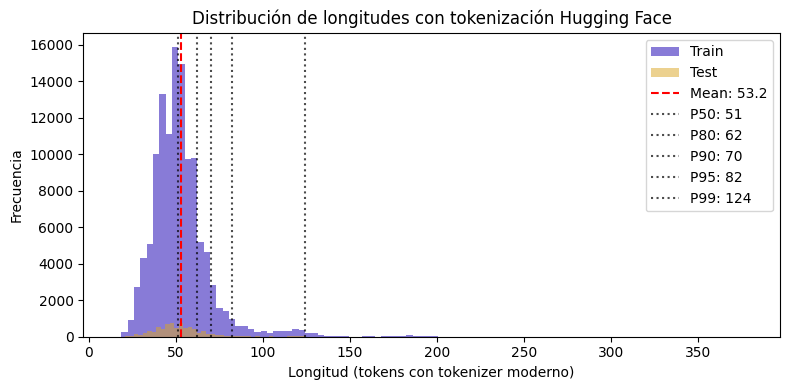

In [12]:
# Analizamos la distribución de longitudes usando el tokenizador moderno
# No aplicamos padding aquí; solo observamos cuántos tokens genera cada texto.
hf_lengths_train = np.array(
    [
        len(tokenizer(text, truncation=False)["input_ids"])
        for text in ds["train"]["text"]
    ]
)

hf_lengths_test = np.array(
    [len(tokenizer(text, truncation=False)["input_ids"]) for text in ds["test"]["text"]]
)

percentiles = [50, 80, 90, 95, 99]
pvals_hf_train = [int(np.percentile(hf_lengths_train, p)) for p in percentiles]

plt.figure(figsize=(8, 4))
plt.hist(hf_lengths_train, bins=100, color="slateblue", alpha=0.8, label="Train")
plt.hist(hf_lengths_test, bins=100, color="goldenrod", alpha=0.5, label="Test")
plt.axvline(
    hf_lengths_train.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {hf_lengths_train.mean():.1f}",
)

for p, val in zip(percentiles, pvals_hf_train):
    plt.axvline(val, color="black", linestyle=":", alpha=0.7, label=f"P{p}: {val}")

plt.xlabel("Longitud (tokens con tokenizer moderno)")
plt.ylabel("Frecuencia")
plt.title("Distribución de longitudes con tokenización Hugging Face")
plt.legend()
plt.tight_layout()
plt.show()

**Notas:**

A partir de la distribución de longitudes tokenizadas, se definirá un valor máximo de secuencia (`max_length`) que permita cubrir la mayor parte de los ejemplos sin introducir un costo computacional excesivo.   

En este caso, se busca un equilibrio entre preservar información textual y mantener el entrenamiento manejable.

Para este notebook se utilizará un valor de `max_length = 100` (pero se podria configurar despues).

### Tokenización del dataset (Completo)

El dataset de Hugging face lo tokenizaremos y lo dejamos listo para ser utilizado como un Dataset de pytorch

In [13]:
# Definimos la longitud máxima de secuencia a utilizar
max_length = 100


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )


# Aplicamos la tokenización al dataset completo
tokenized_ds = ds.map(tokenize_batch, batched=True)

# Renombramos la etiqueta para que sea más natural al trabajar en PyTorch
tokenized_ds = tokenized_ds.rename_column("label", "labels")

# Seleccionamos solo las columnas necesarias para el entrenamiento
tokenized_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"],
)

print(tokenized_ds)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})


In [14]:
tokenized_ds["train"][0]

{'labels': tensor(2),
 'input_ids': tensor([  101,  2813,  2358,  1012,  6468, 15020,  2067,  2046,  1996,  2304,
          1006, 26665,  1007, 26665,  1011,  2460,  1011, 19041,  1010,  2813,
          2395,  1005,  1055,  1040, 11101,  2989,  1032,  2316,  1997, 11087,
          1011, 22330,  8713,  2015,  1010,  2024,  3773,  2665,  2153,  1012,
           102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,

**notas:**

Con estos pasos queda preparada la representación tokenizada del dataset para su uso posterior en PyTorch. En particular, cada noticia queda representada mediante una secuencia de identificadores (`input_ids`) y una máscara de atención (`attention_mask`) que indica cuáles posiciones corresponden a texto real y cuáles a padding.

En esta etapa no se construirán aún los `DataLoader`, ya que dicho proceso se integrará en la siguiente sección del notebook, donde se definirán los componentes comunes del pipeline de entrenamiento y evaluación. De esta manera, parámetros como el tamaño del batch podrán manejarse de forma más flexible dentro del proceso experimental.

Desde el punto de vista metodológico, esta sección también introduce una diferencia relevante frente al taller anterior: el uso de un tokenizador moderno basado en subpalabras.

## Separación de dataset en Train, Validation & Test

Partimos el conjunto de entrenamiento original en entrenamiento y validación

In [15]:
# Usamos una partición 90/10 manteniendo la semilla definida al inicio del notebook.
train_val_split = tokenized_ds["train"].train_test_split(test_size=0.1, seed=SEED)

train_dataset = train_val_split["train"]
val_dataset = train_val_split["test"]
test_dataset = tokenized_ds["test"]

print("Tamaños de los conjuntos:")
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Tamaños de los conjuntos:
Train: 108000
Validation: 12000
Test: 7600


In [16]:
from collections import Counter

# Revisamos la distribución de clases en cada subconjunto
train_counts = Counter([label.item() for label in train_dataset["labels"]])
val_counts = Counter([label.item() for label in val_dataset["labels"]])
test_counts = Counter([label.item() for label in test_dataset["labels"]])

num_classes = len(ds["train"].features["label"].names)

split_distribution = pd.DataFrame(
    {
        "Clase": class_names,
        "Train": [train_counts[i] for i in range(num_classes)],
        "Validation": [val_counts[i] for i in range(num_classes)],
        "Test": [test_counts[i] for i in range(num_classes)],
    }
)

split_distribution

,Clase,Train,Validation,Test
0,World,27070,2930,1900
1,Sports,26996,3004,1900
2,Business,26962,3038,1900
3,Sci/Tech,26972,3028,1900


**Notas:**

La distribución de clases en los subconjuntos obtenidos se mantiene razonablemente balanceada, lo cual resulta conveniente para el entrenamiento y la evaluación de los modelos. Dado que AG News es un dataset relativamente equilibrado, contamos con una proporción similar de ejemplos por categoría sin necesidad de aplicar técnicas adicionales de balanceo.

# 4. Definición de arquitecturas

En esta sección se presentan las arquitecturas base que serán utilizadas en el desarrollo del notebook. Dado que el objetivo del taller es comparar un enfoque secuencial clásico frente a un enfoque basado en Transformers, primero se definirán los componentes comunes del pipeline de entrenamiento y evaluación, de modo que ambos modelos compartan condiciones experimentales comparables. Posteriormente, se describirá la arquitectura base LSTM como modelo de referencia y la arquitectura base Transformer como enfoque principal del taller.

La intención de esta organización es separar con claridad los elementos compartidos del pipeline de aquellos que son propios de cada arquitectura. De esta manera, la comparación entre modelos resulta más ordenada, reproducible y consistente.

## Componentes comunes

Esta subsección reúne los elementos que serán compartidos por los modelos LSTM y Transformer, incluyendo aspectos de configuración general del experimento, construcción de los `DataLoader`, funciones de entrenamiento por época, funciones de evaluación y utilidades para el análisis de resultados.

Definimos estos componentes con el objetivo de mantener una comparación más justa entre ambos enfoques, ya que los cambios observados en el desempeño podrán asociarse principalmente a la arquitectura del modelo y no a diferencias en el procedimiento de entrenamiento o evaluación.

### Hiperparametros comunes

In [17]:
# Definimos los parámetros generales del experimento comparativo inicial (LSTM VS Transformer)
# Estos parámetros se pueden ajustar posteriormente para explorar su impacto
# en el rendimiento del modelo Transformer particularmente.

batch_size_base = 64
num_epochs_base = 7
learning_rate_base = 1e-3

num_classes = len(ds["train"].features["label"].names)
class_names = ds["train"].features["label"].names
vocab_size = tokenizer.vocab_size

print("Parámetros generales del experimento:")
print(f"Batch size: {batch_size_base}")
print(f"Número de épocas: {num_epochs_base}")
print(f"Learning rate: {learning_rate_base}")
print(f"Número de clases: {num_classes}")
print(f"Clases: {class_names}")
print(f"Tamaño del vocabulario: {vocab_size}")
print(f"Longitud máxima de secuencia: {max_length}")

Parámetros generales del experimento:
Batch size: 64
Número de épocas: 7
Learning rate: 0.001
Número de clases: 4
Clases: ['World', 'Sports', 'Business', 'Sci/Tech']
Tamaño del vocabulario: 30522
Longitud máxima de secuencia: 100


### DataLoaders

In [18]:
# Continuamos con la definición de los dataloaders para facilitar el entrenamiento y evaluación de nuestros modelos


def create_dataloaders(train_dataset, val_dataset, test_dataset, batch_size):
    """
    Crea los DataLoaders para entrenamiento, validación y prueba.
    Solo el DataLoader de entrenamiento tiene shuffle=True para mejorar la generalización.

    Args:
        train_dataset: conjunto de entrenamiento
        val_dataset: conjunto de validación
        test_dataset: conjunto de prueba
        batch_size: tamaño del batch

    Returns:
        train_loader, val_loader, test_loader
    """

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


# Construimos los DataLoaders a partir de los datasets definidos previamente
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset, batch_size=batch_size_base
)

print("DataLoaders creados correctamente.")
print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(val_loader)}")
print(f"Número de batches de prueba: {len(test_loader)}")

DataLoaders creados correctamente.
Número de batches de entrenamiento: 1688
Número de batches de validación: 188
Número de batches de prueba: 119


In [19]:
# Inspeccionamos un batch para verificar la estructura de los datos
batch = next(iter(train_loader))

print("Claves del batch:", batch.keys())
print("Shape de input_ids:", batch["input_ids"].shape)
print("Shape de attention_mask:", batch["attention_mask"].shape)
print("Shape de labels:", batch["labels"].shape)

Claves del batch: dict_keys(['labels', 'input_ids', 'attention_mask'])
Shape de input_ids: torch.Size([64, 100])
Shape de attention_mask: torch.Size([64, 100])
Shape de labels: torch.Size([64])


**Nota:**

En este caso no es necesario un `collate_fn` para los dataloaders porque nuestro dataset ya tiene incluida la mascara de atención y secuencias de la misma longitud, gracias al tokenizador utilizado.


------

### Funciones de entrenamiento y evaluacion de epocas

In [20]:
# Definimos la función general que ejecuta una época completa sobre el conjunto de entrenamiento.
# En cada iteración, el modelo recibe un batch de datos, calcula las predicciones, evalúa la función de pérdida,
# actualiza sus parámetros mediante backpropagation y acumula métricas de desempeño.


def train_one_epoch(model, dataloader, optimizer, criterion, device, max_norm=1.0):
    """
    Entrena el modelo durante una época completa.

    Args:
        model: modelo de PyTorch
        dataloader: DataLoader del conjunto de entrenamiento
        optimizer: optimizador
        criterion: función de pérdida
        device: dispositivo de cómputo
        max_norm: valor máximo para el gradiente clipping (opcional)

    Returns:
        epoch_loss: pérdida promedio de la época
        epoch_accuracy: accuracy de la época
        epoch_f1: F1 macro de la época
    """

    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in tqdm(dataloader, desc="Entrenando", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Reiniciamos gradientes
        optimizer.zero_grad()

        # Forward pass
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        # Backpropagation
        loss.backward()

        # gradient clipping para evitar exploding gradients (especialmente util para LSTM)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)

        # Actualizamos los parámetros del modelo
        optimizer.step()

        # Acumulamos pérdida
        total_loss += loss.item()

        # Obtenemos predicciones
        preds = torch.argmax(logits, dim=1)

        # Acumulamos predicciones y etiquetas para métricas
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    # Métricas de la época
    epoch_loss = total_loss / len(dataloader)
    epoch_accuracy = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_accuracy, epoch_f1

La función anterior concentra la lógica básica de entrenamiento para una época completa y será reutilizada posteriormente con ambas arquitecturas. Un aspecto importante es que se asume una interfaz común para los modelos, de modo que tanto el LSTM como el Transformer reciban `input_ids` y `attention_mask` como entradas.


-----

In [21]:
# Ahora, definimos la función general de evaluación para validación o prueba.
# Esta función calcula pérdida y métricas sin actualizar los parámetros del modelo.


def evaluate_model(model, dataloader, criterion, device):
    """
    Evalúa el modelo sobre un conjunto de datos.

    Args:
        model: modelo de PyTorch
        dataloader: DataLoader del conjunto a evaluar
        criterion: función de pérdida
        device: dispositivo de cómputo

    Returns:
        epoch_loss: pérdida promedio
        epoch_accuracy: accuracy
        epoch_f1: F1 macro
        all_labels: etiquetas reales
        all_preds: predicciones del modelo
    """

    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluando", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # Forward pass
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            # Acumulamos pérdida
            total_loss += loss.item()

            # Obtenemos predicciones
            preds = torch.argmax(logits, dim=1)

            # Acumulamos predicciones y etiquetas
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    # Métricas del conjunto evaluado
    epoch_loss = total_loss / len(dataloader)
    epoch_accuracy = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_accuracy, epoch_f1, all_labels, all_preds

La función anterior será utilizada tanto durante el seguimiento del entrenamiento sobre el conjunto de validación como en la evaluación final sobre el conjunto de prueba. Además de las métricas agregadas, se conservan las etiquetas reales y las predicciones del modelo, lo cual permitirá construir posteriormente matrices de confusión y otros análisis comparativos.

----

### Función de entrenamiento completo

Una vez definidas las funciones de entrenamiento por época y evaluación, se implementa una función general que organiza el ciclo completo de entrenamiento del modelo. Esta función se encargará de ejecutar múltiples épocas, registrar las métricas obtenidas en entrenamiento y validación, y conservar la mejor versión del modelo de acuerdo con el desempeño observado en el conjunto de validación.

In [22]:
import copy

# Definimos una función general para entrenar el modelo durante varias épocas.
# La función almacena métricas de entrenamiento y validación, y conserva
# la mejor versión del modelo según el F1 macro en validación.


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    num_epochs,
    max_norm=1.0,
    verbose=True,
):
    """
    Entrena un modelo durante varias épocas y conserva la mejor versión
    según el F1 macro del conjunto de validación.

    Args:
        model: modelo de PyTorch
        train_loader: DataLoader de entrenamiento
        val_loader: DataLoader de validación
        optimizer: optimizador
        criterion: función de pérdida
        device: dispositivo de cómputo
        num_epochs: número de épocas
        max_norm: valor máximo para gradient clipping
        verbose: si True, imprime métricas por época

    Returns:
        history: diccionario con métricas por época
        best_model_state: mejor estado del modelo
        best_val_f1: mejor F1 macro en validación
    """

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_f1": [],
    }

    best_val_f1 = -float("inf")
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch + 1}/{num_epochs}")

        # Entrenamiento
        train_loss, train_acc, train_f1 = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            max_norm=max_norm,
        )

        # Evaluación en validación
        val_loss, val_acc, val_f1, _, _ = evaluate_model(
            model=model, dataloader=val_loader, criterion=criterion, device=device
        )

        # Guardamos métricas
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["val_f1"].append(val_f1)

        if verbose:
            # Mostramos resultados de la época
            print(
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Train F1: {train_f1:.4f}"
            )
            print(
                f"Val Loss:   {val_loss:.4f} | "
                f"Val Acc:   {val_acc:.4f} | "
                f"Val F1:   {val_f1:.4f}"
            )

        # Guardamos el mejor modelo según F1 macro en validación
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = copy.deepcopy(model.state_dict())
            print("Mejor modelo actualizado según val_f1.")

    return history, best_model_state, best_val_f1

### Utilidades para visualizaciones


In [23]:
# Definimos una función para visualizar la evolución de las métricas
# de entrenamiento y validación a lo largo de las épocas.


def plot_training_history(history, title="Historial de entrenamiento"):
    """
    Grafica la evolución de pérdida, accuracy y F1 macro
    para entrenamiento y validación.

    Args:
        history: diccionario con métricas por época
        title: título general de la figura
    """

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Pérdida
    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title("Pérdida")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
    axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Val Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # F1 macro
    axes[2].plot(epochs, history["train_f1"], marker="o", label="Train F1 Macro")
    axes[2].plot(epochs, history["val_f1"], marker="o", label="Val F1 Macro")
    axes[2].set_title("F1 Macro")
    axes[2].set_xlabel("Época")
    axes[2].set_ylabel("F1")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

In [24]:
# Definimos una función para visualizar la matriz de confusión
# a partir de las etiquetas reales y las predicciones del modelo.


def plot_confusion_matrix_from_preds(
    y_true, y_pred, class_names, title="Matriz de confusión"
):
    """
    Grafica la matriz de confusión a partir de etiquetas reales y predichas.

    Args:
        y_true: etiquetas reales
        y_pred: etiquetas predichas
        class_names: nombres de las clases
        title: título de la figura
    """

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Adicional, mostramos el reporte de clasificación para un análisis más detallado
    print("\nReporte de clasificación:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

## Arquitectura base LSTM

Como modelo de referencia, se implementará una arquitectura basada en Long Short-Term Memory (LSTM), la cual representa un enfoque secuencial clásico para tareas de procesamiento de lenguaje natural.

Este tipo de red procesa el texto token por token y construye una representación interna de la secuencia a partir de estados ocultos que resumen la información observada a lo largo del recorrido.

**En este taller, el modelo LSTM se utilizará como baseline para contrastar su desempeño frente al modelo basado en Transformer.**

In [25]:
# Definimos la arquitectura base LSTM para clasificación de texto.
# El modelo recibe secuencias tokenizadas, genera embeddings,
# procesa la secuencia con una capa LSTM y utiliza el último estado oculto
# como representación global para la clasificación final.


class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers,
        num_classes,
        dropout=0.2,
        pad_idx=0,
    ):
        super().__init__()

        # La capa de embedding convierte los IDs de tokens en vectores densos.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embedding_dim, padding_idx=pad_idx
        )

        # La capa LSTM procesa la secuencia de embeddings.
        # Usamos batch_first=True para que la entrada sea [batch_size, seq_len, embedding_dim].
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Dropout adicional (regularización) sobre la representación final
        self.dropout = nn.Dropout(dropout)

        # Clasificador final (sin softmax)
        # CrossEntropyLoss aplicará internamente log-softmax
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask=None):
        # input_ids: [batch_size, seq_len]
        # attention_mask: [batch_size, seq_len]

        # Embeddings
        embedded = self.embedding(input_ids)  # [batch_size, seq_len, embedding_dim]

        # Calculamos la longitud real de cada secuencia
        lengths = attention_mask.sum(dim=1).cpu()

        # Empaquetamos las secuencias para que la LSTM ignore el padding
        packed_embedded = pack_padded_sequence(
            embedded, lengths=lengths, batch_first=True, enforce_sorted=False
        )

        # Pasamos las secuencias empaquetadas por la LSTM
        packed_output, (hidden, cell) = self.lstm(packed_embedded)

        # hidden[-1] corresponde al último estado oculto de la última capa
        final_hidden = hidden[-1]  # [batch_size, hidden_dim]

        # Dropout + capa final a logits
        final_hidden = self.dropout(final_hidden)
        logits = self.classifier(final_hidden)  # [batch_size, num_classes]

        return logits

**Notas:**

La arquitectura anterior define un baseline recurrente sencillo para la tarea de clasificación de noticias. En este caso, cada texto tokenizado es transformado primero en embeddings densos y luego procesado secuencialmente por una capa LSTM. El último estado oculto se utiliza como representación global del documento, a partir de la cual se obtiene la predicción final de clase.

----

## Arquitectura base Transformer

En comparación con el notebook guía del curso, donde se presenta una implementación más manual y pedagógica de algunos componentes internos del Transformer, en este trabajo se adopta una aproximación más aplicada y modular. **En lugar de reconstruir explícitamente mecanismos como la atención multi-cabeza y el bloque Transformer desde cero, se emplearán módulos estándar de PyTorch con el fin de mantener una arquitectura más compacta, reproducible y alineada con prácticas modernas de desarrollo.**

Teniendo en cuenta esto, la arquitectura principal de este taller estará basada en un `TransformerEncoder` implementado con módulos ya disponibles en PyTorch. A diferencia del enfoque recurrente, el Transformer permite procesar la secuencia completa en paralelo y construir embeddings contextuales mediante mecanismos de atención.

Adicionalmente, mientras que en el ejemplo del profesor la salida secuencial del bloque Transformer se aplana (`Flatten`) antes de la clasificación, **en este notebook utilizaremos una estrategia de *mean pooling* con máscara de atención para obtener una representación global de cada noticia.** Esta decisión permite resumir la información contextual de manera más controlad y reducir la dimensionalidad de entrada al clasificador.

In [26]:
# Definimos el positional encoding sinusoidal.
# Esta componente añade información de posición a los embeddings,
# ya que el Transformer por sí solo no tiene noción del orden secuencial.


class PositionalEncoding(nn.Module):
    def __init__(self, emb_dim, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Matriz de positional encodings: [max_len, emb_dim]
        pe = torch.zeros(max_len, emb_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, emb_dim, 2).float() * (-math.log(10000.0) / emb_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Añadimos dimensión batch: [1, max_len, emb_dim]
        pe = pe.unsqueeze(0)

        # Lo registramos como buffer para que se mueva con el modelo,
        # pero no se entrene como parámetro.
        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        x: tensor de shape [batch_size, seq_len, emb_dim]
        """
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)

In [27]:
# Definimos la arquitectura base Transformer para clasificación de texto.
# El modelo genera embeddings, añade positional encoding, procesa la secuencia
# con un TransformerEncoder y luego resume la salida mediante mean pooling
# usando la attention_mask para ignorar el padding.


class TransformerClassifier(nn.Module):
    """
    Clasificador de texto basado en Transformer Encoder.

    Esta arquitectura:
    1) Convierte tokens en embeddings.
    2) Añade codificación posicional sinusoidal.
    3) Procesa la secuencia con un TransformerEncoder.
    4) Aplica mean pooling enmascarado para ignorar padding.
    5) Proyecta la representación global a logits de clasificación.

    Args:
        vocab_size (int): Tamaño del vocabulario.
        emb_dim (int): Dimensión de los embeddings.
        num_heads (int): Número de cabezas de atención.
        ff_dim (int): Dimensión interna del bloque feed-forward.
        num_layers (int): Número de capas del encoder.
        num_classes (int): Número de clases de salida.
        max_len (int): Longitud máxima de secuencia para positional encoding.
        dropout (float, optional): Probabilidad de dropout. Default: 0.2.
        pad_idx (int, optional): Índice del token de padding. Default: 0.
    """

    def __init__(
        self,
        vocab_size,
        emb_dim,
        num_heads,
        ff_dim,
        num_layers,
        num_classes,
        max_len,
        dropout=0.2,
        pad_idx=0,
    ):
        super().__init__()

        # Capa de embedding
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=emb_dim, padding_idx=pad_idx
        )

        # Positional encoding para añadir información de posición a los embeddings
        self.positional_encoding = PositionalEncoding(
            emb_dim=emb_dim, max_len=max_len, dropout=dropout
        )

        # Definimos una capa de TransformerEncoderLayer, que es la unidad básica del encoder.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="relu",
        )

        # El TransformerEncoder se compone de varias capas de encoder_layer apiladas.
        # num_layers define cuántas de estas capas apilamos.
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer, num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        # input_ids: [batch_size, seq_len]
        # attention_mask: [batch_size, seq_len]

        # Embeddings
        x = self.embedding(input_ids)  # [batch_size, seq_len, emb_dim]

        # Escalamos embeddings
        x = x * math.sqrt(x.size(-1))

        # Añadimos información posicional
        x = self.positional_encoding(x)

        # PyTorch espera una máscara donde True indica posiciones a ignorar.
        # Nuestra attention_mask tiene 1 en tokens reales y 0 en padding,
        # así que la invertimos.
        src_key_padding_mask = attention_mask == 0  # [batch_size, seq_len]

        # Pasamos por el encoder
        x = self.transformer_encoder(
            x, src_key_padding_mask=src_key_padding_mask
        )  # [batch_size, seq_len, emb_dim]

        # Mean pooling con máscara para ignorar padding
        mask = attention_mask.unsqueeze(-1).float()  # [batch_size, seq_len, 1]
        x_masked = x * mask
        summed = x_masked.sum(dim=1)  # [batch_size, emb_dim]
        lengths = mask.sum(dim=1).clamp(min=1e-9)  # evitar división por cero
        mean_pooled = summed / lengths

        # Dropout + capa final a logits
        mean_pooled = self.dropout(mean_pooled)
        logits = self.classifier(mean_pooled)  # [batch_size, num_classes]

        return logits

**Notas:**

La arquitectura anterior implementa un clasificador de texto basado en `TransformerEncoder` utilizando módulos estándar de PyTorch. internamente, este componente incorpora mecanismos de atención multi-cabeza, conexiones residuales, normalización y una red feed-forward, todos controlados por diversos hiperparámetros.

Por último, en esta aproximación no se desarrollará un esquema de positional encoding con parámetros entrenables (es decir, learned positional encoding).

-----

### Funcion auxiliar para tunning (Transformer)

A continuación definimos una función que nos permita mantener el tuning de hiperparametros controlado, donde se seleccione una combinación distinta de hiperparámetros los cuales respeten restricciones propias de los transfomers. Por ultimo, la función devuelve un diccionario de facil implementación en la logica de tunning.

In [ ]:
def sample_random_transformer_configs(
    search_space, n_trials, seed=SEED, min_head_dim=32
):
    """
    Genera configuraciones aleatorias sin repetición a partir del espacio de búsqueda,
    respetando restricciones estructurales del Transformer.

    Args:
        search_space: diccionario con listas de valores posibles
        n_trials: número de configuraciones aleatorias a generar
        seed: semilla para reproducibilidad
        min_head_dim: dimensión mínima permitida por cabeza de atención

    Returns:
        configs: lista de diccionarios con configuraciones únicas y válidas
    """
    random.seed(seed)

    all_configs = []
    seen = set()

    max_attempts = 5000
    attempts = 0

    while len(all_configs) < n_trials and attempts < max_attempts:
        config = {key: random.choice(values) for key, values in search_space.items()}

        # Validación estructural entre embedding_dim y num_heads
        embedding_dim = config["embedding_dim"]
        num_heads = config["num_heads"]

        # 1. El embedding debe ser divisible por el número de cabezas
        if embedding_dim % num_heads != 0:
            attempts += 1
            continue

        # 2. Cada cabeza debe tener una dimensión mínima razonable
        head_dim = embedding_dim // num_heads
        if head_dim < min_head_dim:
            attempts += 1
            continue

        # Convertimos a tupla ordenada para detectar duplicados
        config_tuple = tuple(sorted(config.items()))

        if config_tuple not in seen:
            seen.add(config_tuple)
            all_configs.append(config)

        attempts += 1

    if len(all_configs) < n_trials:
        print(
            f"Advertencia: solo se pudieron generar {len(all_configs)} "
            f"configuraciones válidas únicas de {n_trials} solicitadas."
        )

    return all_configs

# 5. Entrenamiento y evaluación de modelos

Una vez definidas las arquitecturas base del modelo LSTM y del modelo Transformer, en esta sección se lleva a cabo su entrenamiento y evaluación bajo un mismo pipeline experimental.

**Importante notar que los parametros escogidos para el entrenamiento del modelo LSTM y Transformer son relativamente similares (en la medida de lo posible), esto con la finalidad de hacer lo mas justo posible la comparación**

## LSTM

Antes de iniciar el ciclo de entrenamiento, es importante resumir las características principales del modelo LSTM que se utilizará como baseline en este notebook.

**Componentes clave de la arquitectura**

- **Capa de embeddings:**  
  Convierte los IDs de tokens en vectores densos entrenables. En este caso, se utiliza una dimensión de embeddings de 128 y se define explícitamente el token de padding para que su representación no afecte el aprendizaje del modelo.

- **Capa LSTM:**  
  La secuencia de embeddings es procesada de manera recurrente mediante una capa LSTM. Adicionalmente, se emplea `pack_padded_sequence` a partir de la `attention_mask`, lo que permite ignorar los tokens de relleno durante la recurrencia y obtener una representación más fiel del contenido real de cada noticia.

- **Representación global del texto:**  
  Como representación final del documento se utiliza el último estado oculto de la LSTM, correspondiente a la última capa. Esta salida actúa como un resumen secuencial del texto completo.

- **Regularización y clasificación:**  
  Sobre la representación final se aplica una capa de dropout para reducir riesgo de sobreajuste. Posteriormente, una capa lineal proyecta dicha representación al espacio de las 4 clases del problema, produciendo logits que serán optimizados mediante `CrossEntropyLoss`.

**Resumen de hiperparámetros**
- **Numero de epocas:** `num_epochs_base = 7`  
- **Dimensión de embeddings:** 128  
- **Dimensión oculta de la LSTM:** 64  
- **Número de capas LSTM:** 1  
- **Dropout:** 0.2  
- **Optimizador:** AdamW (`lr=1e-3`)  
- **Función de pérdida:** CrossEntropyLoss  
- **Longitud máxima de secuencia:** `max_length = 100`  
- **Tamaño de batch:** `batch_size_base = 64`  
- **Tamaño del vocabulario:** `vocab_size = 30522`  


In [ ]:
# Hiperparámetros específicos del modelo LSTM
lstm_embedding_dim = 128
lstm_hidden_dim = 64
lstm_num_layers = 1
lstm_dropout = 0.2

print("Hiperparámetros del modelo LSTM:")
print(f"Embedding dim: {lstm_embedding_dim}")
print(f"Hidden dim: {lstm_hidden_dim}")
print(f"Num layers: {lstm_num_layers}")
print(f"Dropout: {lstm_dropout}")

# Instanciamos el modelo
lstm_model = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=lstm_embedding_dim,
    hidden_dim=lstm_hidden_dim,
    num_layers=lstm_num_layers,
    num_classes=num_classes,
    dropout=lstm_dropout,
    pad_idx=tokenizer.pad_token_id,
).to(device)

# Definimos función de pérdida y optimizador
lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=learning_rate_base)

total_params = sum(p.numel() for p in lstm_model.parameters())
trainable_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)

print("\nModelo LSTM instanciado correctamente:")
print(f"Parámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}\n")
print(lstm_model)

Hiperparámetros del modelo LSTM:
Embedding dim: 128
Hidden dim: 64
Num layers: 1
Dropout: 0.2

Modelo LSTM instanciado correctamente:
Parámetros totales: 3,956,740
Parámetros entrenables: 3,956,740

LSTMClassifier(
  (embedding): Embedding(30522, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)


In [ ]:
# Entrenamos el modelo LSTM y medimos el tiempo total
start_time = time.time()

lstm_history, lstm_best_state, lstm_best_val_f1 = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=lstm_optimizer,
    criterion=lstm_criterion,
    device=device,
    num_epochs=num_epochs_base,
    max_norm=1.0,
)

end_time = time.time()
training_time = end_time - start_time

print(f"\nMejor F1 macro en validación (LSTM): {lstm_best_val_f1:.4f}")
print(
    f"Tiempo total de entrenamiento del LSTM: {training_time:.2f} segundos ({training_time/60:.2f} minutos)"
)


Época 1/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Train Loss: 0.6026 | Train Acc: 0.7639 | Train F1: 0.7633
Val Loss:   0.3729 | Val Acc:   0.8719 | Val F1:   0.8715
Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

...

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Train Loss: 0.1268 | Train Acc: 0.9606 | Train F1: 0.9606
Val Loss:   0.3034 | Val Acc:   0.9087 | Val F1:   0.9087

Época 7/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Train Loss: 0.1024 | Train Acc: 0.9688 | Train F1: 0.9688
Val Loss:   0.3337 | Val Acc:   0.9083 | Val F1:   0.9082

Mejor F1 macro en validación (LSTM): 0.9088
Tiempo total de entrenamiento del LSTM: 162.84 segundos (2.71 minutos)


Mejor estado del modelo LSTM cargado correctamente.


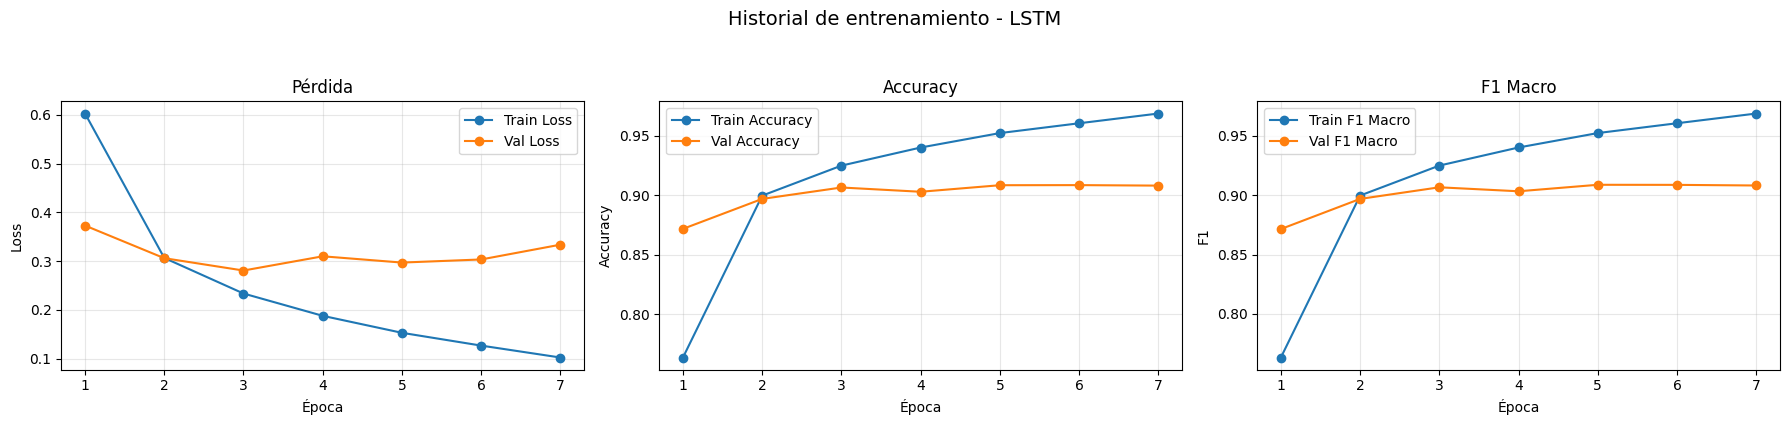

In [ ]:
# Cargamos la mejor versión del modelo según validación
lstm_model.load_state_dict(lstm_best_state)
print("Mejor estado del modelo LSTM cargado correctamente.")

# Graficamos la evolución del entrenamiento del modelo LSTM
plot_training_history(lstm_history, title="Historial de entrenamiento - LSTM")


**Notas:**

- **El modelo LSTM muestra una convergencia rápida**, alcanzando más del 90% de F1 en validación en solo tres épocas. Tanto la accuracy como el F1 de validación crecen rápidamente entre las épocas 1 y 4, pasando aproximadamente de 0.87 a 0.91.
- Las métricas de entrenamiento continúan mejorando hasta la última época, mientras que las métricas de validación se estabilizan alrededor de la época 3–4. Este comportamiento sugiere el inicio de **sobreajuste** desde este punto.
- Analizando las graficas, se observa una **brecha creciente entre entrenamiento y validación**. Mientras las métricas de entrenamiento continúan mejorando, las métricas de validación se mantienen relativamente estables. Esto genera una **separación progresiva entre ambas curvas.**

## Transformer

Una vez establecido el baseline recurrente, procedemos con el entrenamiento del modelo basado en Transformer, que constituye la arquitectura principal de este taller. A diferencia del LSTM, este enfoque procesa la secuencia completa en paralelo y construye representaciones contextuales mediante mecanismos de atención, lo que le permite modelar relaciones entre palabras de forma más flexible.

**Componentes clave de la arquitectura**

- **Capa de embeddings:**  
  Convierte los IDs de tokens en vectores densos entrenables de dimensión 128. Al igual que en el LSTM, se especifica el token de padding para mantener consistencia en la representación de entrada.

- **Positional Encoding:**  
  Debido a que el Transformer no incorpora de forma inherente el orden secuencial, se añade un positional encoding sinusoidal para introducir información de posición dentro de la secuencia.

- **Transformer Encoder:**  
  La secuencia enriquecida con información posicional es procesada mediante capas `TransformerEncoder`, construidas con módulos estándar de PyTorch. Esto permite utilizar una implementación más modular y cercana a prácticas actuales, en contraste con el notebook guía del profesor, donde varios componentes internos del Transformer son implementados manualmente con fines didácticos.

- **Agregación global mediante mean pooling con máscara:**  
  En lugar de aplanar toda la salida del encoder, se utiliza una estrategia de *mean pooling* sobre los tokens válidos de la secuencia, ignorando el padding mediante la `attention_mask`. Esta decisión produce una representación global más compacta y controlada del documento.

- **Regularización y clasificación:**  
  Sobre la representación final se aplica dropout, seguido de una capa lineal que proyecta al espacio de las 4 clases del problema. Los logits obtenidos son optimizados mediante `CrossEntropyLoss`.

**Resumen de hiperparámetros**
- **Numero de epocas:** `num_epochs_base = 7`  
- **Dimensión de embeddings (`d_model`):** 128  
- **Número de cabezas de atención:** 4  
- **Dimensión feedforward interna:** 64  
- **Número de capas encoder:** 1  
- **Dropout:** 0.2  
- **Optimizador:** AdamW (`lr=1e-3`)  
- **Función de pérdida:** CrossEntropyLoss  
- **Longitud máxima de secuencia:** `max_length = 100`  
- **Tamaño de batch:** `batch_size_base = 64`  
- **Tamaño del vocabulario:** `vocab_size = 30522`  

In [ ]:
# Hiperparámetros específicos del modelo Transformer
# Escogemos unos hiperparámetros razonables y similares a los del LSTM para una comparación inicial.

transformer_embedding_dim = 128
transformer_num_heads = 4
transformer_ff_dim = 64
transformer_num_layers = 1
transformer_dropout = 0.2

print("Hiperparámetros del modelo Transformer:")
print(f"Embedding dim (d_model): {transformer_embedding_dim}")
print(f"Número de cabezas: {transformer_num_heads}")
print(f"Dimensión feedforward: {transformer_ff_dim}")
print(f"Número de capas encoder: {transformer_num_layers}")
print(f"Dropout: {transformer_dropout}")

# Instanciamos el modelo
transformer_model = TransformerClassifier(
    vocab_size=vocab_size,
    emb_dim=transformer_embedding_dim,
    num_heads=transformer_num_heads,
    ff_dim=transformer_ff_dim,
    num_layers=transformer_num_layers,
    num_classes=num_classes,
    max_len=max_length,
    dropout=transformer_dropout,
    pad_idx=tokenizer.pad_token_id,
).to(device)

# Definimos función de pérdida y optimizador
transformer_criterion = nn.CrossEntropyLoss()
transformer_optimizer = torch.optim.AdamW(
    transformer_model.parameters(), lr=learning_rate_base
)

total_params = sum(p.numel() for p in transformer_model.parameters())
trainable_params = sum(
    p.numel() for p in transformer_model.parameters() if p.requires_grad
)

print("\nModelo Transformer instanciado correctamente:")
print(f"Parámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}\n")
print(transformer_model)

Hiperparámetros del modelo Transformer:
Embedding dim (d_model): 128
Número de cabezas: 4
Dimensión feedforward: 64
Número de capas encoder: 1
Dropout: 0.2

Modelo Transformer instanciado correctamente:
Parámetros totales: 3,990,468
Parámetros entrenables: 3,990,468

TransformerClassifier(
  (embedding): Embedding(30522, 128, padding_idx=0)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=64, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=64, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-0

In [ ]:
# Entrenamos el modelo Transformer
start_time = time.time()

transformer_history, transformer_best_state, transformer_best_val_f1 = train_model(
    model=transformer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=transformer_optimizer,
    criterion=transformer_criterion,
    device=device,
    num_epochs=num_epochs_base,
    max_norm=1.0,
)

end_time = time.time()
training_time = end_time - start_time

print(f"\nMejor F1 macro en validación (Transformer): {transformer_best_val_f1:.4f}")
print(
    f"Tiempo total de entrenamiento del Transformer: {training_time:.2f} segundos ({training_time/60:.2f} minutos)"
)


Época 1/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Train Loss: 0.7700 | Train Acc: 0.6998 | Train F1: 0.6992
Val Loss:   0.5102 | Val Acc:   0.8193 | Val F1:   0.8187
Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

...

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Train Loss: 0.3422 | Train Acc: 0.8825 | Train F1: 0.8823
Val Loss:   0.3485 | Val Acc:   0.8896 | Val F1:   0.8894
Mejor modelo actualizado según val_f1.

Época 7/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Train Loss: 0.3230 | Train Acc: 0.8888 | Train F1: 0.8886
Val Loss:   0.3378 | Val Acc:   0.8946 | Val F1:   0.8946
Mejor modelo actualizado según val_f1.

Mejor F1 macro en validación (Transformer): 0.8946
Tiempo total de entrenamiento del Transformer: 137.64 segundos (2.29 minutos)


Mejor estado del modelo Transformer cargado correctamente.


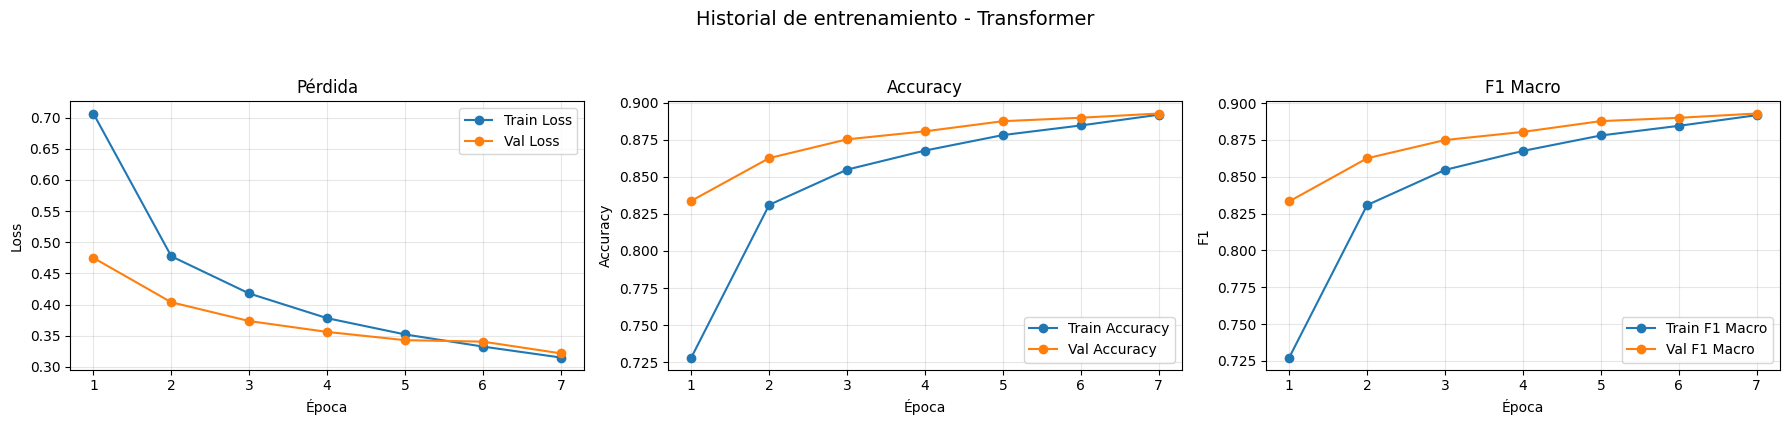

In [ ]:
# Cargamos la mejor versión del modelo según validación
transformer_model.load_state_dict(transformer_best_state)
print("Mejor estado del modelo Transformer cargado correctamente.")

# Graficamos la evolución del entrenamiento del modelo Transformer
plot_training_history(
    transformer_history, title="Historial de entrenamiento - Transformer"
)

**Notas:**

- El modelo Transformer desde la primera época ya parte de métricas relativamente altas, y tanto la accuracy como el F1 macro de validación se mantienen alrededor o cercano a 0.90 durante todo el entrenamiento, con una mejora lenta pero sostenida hacia las últimas épocas.
- En conjunto, las gráficas y metricas muestran que **el Transformer tiene un comportamiento más estable y menos propenso al sobreajuste temprano que el LSTM.** Sin embargo, la mejora absoluta en validación es más moderada, por lo que su principal fortaleza en este experimento parece estar más en la estabilidad del aprendizaje que en una ganancia drástica de desempeño.

## Resultados

Una vez completado el entrenamiento de ambos modelos, los evaluaremos sobre el conjunto de prueba utilizando la mejor versión observada en validación. Además de las métricas globales, se analiza la matriz de confusión y el reporte por clase, con el fin de obtener una visión más completa del comportamiento de los modelos.

### Evaluación de modelos en test set

El conjunto de pruebas contiene 7,600 ejemplos de noticias distribuidas equitativamente entre las 4 categorías (1,900 ejemplos por clase).

In [ ]:
# Diccionario con los modelos y sus funciones de pérdida
models = {
    "LSTM": {"model": lstm_model, "criterion": lstm_criterion},
    "Transformer": {"model": transformer_model, "criterion": transformer_criterion},
}

results = {}

# Evaluación de ambos modelos
for name, config in models.items():
    test_loss, test_acc, test_f1, y_true, y_pred = evaluate_model(
        model=config["model"],
        dataloader=test_loader,
        criterion=config["criterion"],
        device=device,
    )

    results[name] = {
        "loss": test_loss,
        "accuracy": test_acc,
        "f1": test_f1,
        "y_true": y_true,
        "y_pred": y_pred,
    }

# Mostrar resultados comparables
for name, res in results.items():
    print(f"Resultados finales en test - {name}")
    print(f"Test Loss: {res['loss']:.4f}")
    print(f"Test Accuracy: {res['accuracy']:.4f}")
    print(f"Test F1 Macro: {res['f1']:.4f}")
    print("-" * 40)

Evaluando:   0%|          | 0/119 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/119 [00:00<?, ?it/s]

Resultados finales en test - LSTM
Test Loss: 0.2979
Test Accuracy: 0.9072
Test F1 Macro: 0.9074
----------------------------------------
Resultados finales en test - Transformer
Test Loss: 0.3402
Test Accuracy: 0.8964
Test F1 Macro: 0.8963
----------------------------------------


**Notas:**
- **El rendimiento global en el test set fue muy similar entre arquitecturas**. Bajo el mismo pipeline, mismos datos, tokenización, longitud de secuencia, batch size y número de épocas, ambos modelos alcanzan resultados casi equivalentes. Cabe destacar que el modelo LSTM obtiene una ligera ventaja en Accuracy y F1 Macro (~0.91 vs ~0.90).

Dado que las métricas globales son muy cercanas, el siguiente paso lógico es analizar las matrices de confusión y las métricas por clase, para identificar si alguno de los modelos maneja mejor ciertas categorías específicas o presenta patrones de error distintos.


### Matriz de confusiones

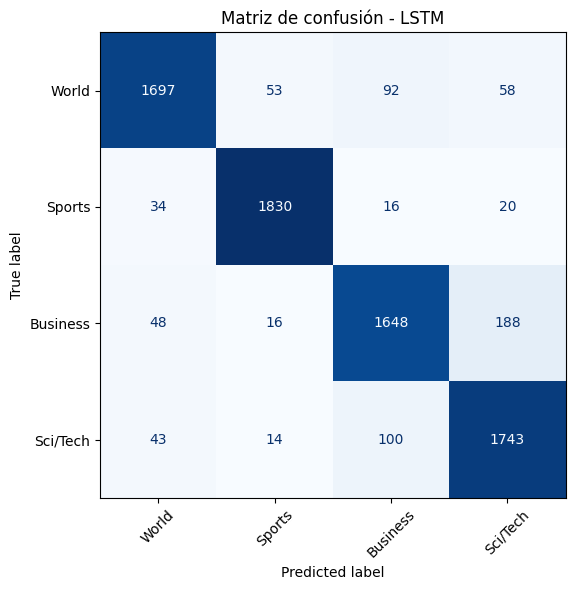


Reporte de clasificación:
              precision    recall  f1-score   support

       World     0.9314    0.8932    0.9119      1900
      Sports     0.9566    0.9632    0.9599      1900
    Business     0.8879    0.8674    0.8775      1900
    Sci/Tech     0.8676    0.9174    0.8918      1900

    accuracy                         0.9103      7600
   macro avg     0.9109    0.9103    0.9103      7600
weighted avg     0.9109    0.9103    0.9103      7600



In [ ]:
# Matriz de confusión del modelo LSTM en test
plot_confusion_matrix_from_preds(
    y_true=results["LSTM"]["y_true"],
    y_pred=results["LSTM"]["y_pred"],
    class_names=class_names,
    title="Matriz de confusión - LSTM",
)

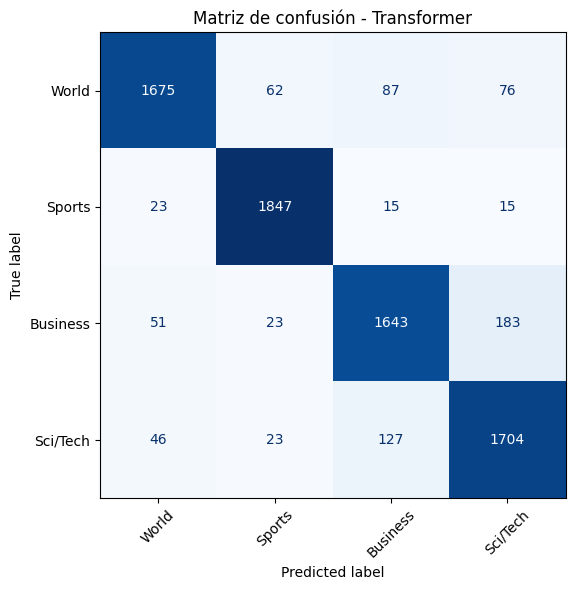


Reporte de clasificación:
              precision    recall  f1-score   support

       World     0.9331    0.8816    0.9066      1900
      Sports     0.9448    0.9721    0.9582      1900
    Business     0.8777    0.8647    0.8712      1900
    Sci/Tech     0.8615    0.8968    0.8788      1900

    accuracy                         0.9038      7600
   macro avg     0.9043    0.9038    0.9037      7600
weighted avg     0.9043    0.9038    0.9037      7600



In [ ]:
# Matriz de confusión del modelo Transformer en test
plot_confusion_matrix_from_preds(
    y_true=results["Transformer"]["y_true"],
    y_pred=results["Transformer"]["y_pred"],
    class_names=class_names,
    title="Matriz de confusión - Transformer",
)

**Notas:**

- **El LSTM muestra un rendimiento ligeramente más equilibrado entre clases**. Aunque las métricas globales ya indicaban una pequeña ventaja del LSTM, el reporte por clase confirma que cuenta con un recall ligeramente mayor en World y Sci/Tech y un F1 ligeramente superior en tres de las cuatro clases.
- **El Transformer presenta un comportamiento muy fuerte en Sports**, superando al modelo LSTM en metricas como el recall, pero presenta mayor confusión entre Business y Sci/Tech.

----

### Discusión y comentarios

En esta sección se compararon los dos modelos evaluados bajo una misma configuración base de entrenamiento, con el objetivo de analizar su comportamiento en condiciones lo más comparables posible.

----

**- Comparación general de resultados**

A nivel global, ambos modelos alcanzaron un desempeño muy cercano en el conjunto de prueba. Esto sugiere que, bajo una configuración base y sin tuning específico, las dos arquitecturas son capaces de resolver de forma competitiva la tarea de clasificación de noticias.

| Modelo | Test Loss | Test Accuracy | Test F1 Macro |
|---|---:|---:|---:|
| LSTM | 0.2931 | 0.91 | 0.91 |
| Transformer | 0.3428 | 0.89| 0.89|

Aunque la diferencia no es grande, el modelo **LSTM obtiene una ligera ventaja en accuracy y F1 macro**, mientras que el **Transformer alcanza una pérdida ligeramente menor**. Esta comparación tiene valor precisamente porque se realizó bajo condiciones homogéneas.

---

**- Comparación desde la arquitectura**

En teoría, la arquitectura del Transformer ofrece una mayor flexibilidad para capturar dependencias entre palabras distantes y relaciones más globales dentro del texto. Sin embargo, en esta configuración base esa ventaja estructural no se tradujo en una mejora clara sobre el LSTM. Esto no implica que el Transformer sea inferior, sino que **su potencial no necesariamente se manifiesta de forma automática en configuraciones pequeñas o poco ajustadas**. Consideramos que el Transformer podria tener una mejora sobre el LSTM dependiendo más del ajuste fino de hiperparámetros, del número de capas, del número de cabezas, del tamaño de los embeddings, de la naturaleza de los datos e incluso de un entrenamiento más prolongado.

---

**- Comparación del proceso de entrenamiento**

A partir de las curvas de entrenamiento y validación, se observan diferencias interesantes en la dinámica de aprendizaje de ambos modelos.

El **LSTM mostró una convergencia más rápida**, alcanzando valores altos de desempeño en pocas épocas. También mostró señales de estabilización temprana en validación y una separación progresiva entre entrenamiento y validación, lo que sugiere el inicio de cierto sobreajuste.

Por su parte, el **Transformer presentó un aprendizaje más gradual y estable**. Sus métricas de validación crecieron de manera más sostenida y sin mostrar una brecha tan marcada respecto al entrenamiento en las primeras épocas. Este comportamiento sugiere una dinámica menos agresiva y, al menos en este experimento, una menor propensión al sobreajuste temprano.

También se observó que el **Transformer requiere un mayor tiempo de procesamiento** que el LSTM bajo esta comparación base. Esto es consistente con la propia naturaleza de la arquitectura, ya que el cálculo de atención introduce un costo computacional adicional y puede verse influido por decisiones de diseño como el número de cabezas de atención y la dimensionalidad interna del modelo.


----

**- Patrones de error observados en las matrices de confusión**

Las matrices de confusión muestran que la principal fuente de error en ambos modelos se concentra en la frontera entre **Business** y **Sci/Tech**. Este patrón es especialmente relevante porque aparece en ambas arquitecturas. El hecho de que dos modelos tan distintos fallen de forma similar en esa zona sugiere que la dificultad no depende exclusivamente del tipo de red utilizada, sino también de la propia naturaleza semántica del dataset. Esto tiene bastante sentido: noticias de negocios y tecnología comparten con frecuencia entidades, temas y vocabulario.

En contraste, la clase **Sports** fue claramente la más fácil de separar. Ambos modelos obtuvieron allí sus mejores métricas, lo que probablemente se explica por un vocabulario más específico y distintivo. Este comportamiento es coherente con lo observado previamente en el análisis exploratorio, donde el dominio deportivo tendía a mostrar señales léxicas más claras.

---

**- Discusión final:**

Una lectura apresurada de los resultados podría llevar a concluir que el LSTM “es mejor” que el Transformer para esta tarea. Sin embargo, esa afirmación sería demasiado fuerte para el alcance de este experimento.Lo que realmente muestran estos resultados es que, **bajo una configuración base, relativamente sencilla y sin tuning**, el LSTM fue capaz de competir e incluso superar ligeramente al Transformer.

Al mismo tiempo, también es razonable pensar que el **Transformer podría superar al LSTM con un ajuste más cuidadoso**. Esta hipótesis se sostiene por varias razones:

- Su desempeño fue ya competitivo incluso sin una optimización específica
- Mostró una dinámica de entrenamiento más estable
- Su arquitectura tiene mayor capacidad para modelar relaciones globales en el texto

En la siguiente sección, profundizaremos en un intento de mejorar los resultados del modelo Transformer a partir de un ligero tuning de hiperparametros y una configuración mas robusta.

# 6. ⚠ Tunning del Transformer (OJO)
**(PREFERIBLEMENTE NO CORRER ESTA SECCION POR TIEMPO DE PROCESAMIENTO)**
----


En base a los hallazgos de la sección anterior, en esta sección realizaremos un ajuste sencillo de hiperparámetros con el fin de explorar configuraciones que puedan mejorar su desempeño en la tarea de clasificación de noticias. El objetivo de esta etapa no es encontrar la configuración óptima absoluta, sino analizar si pequeñas variaciones en algunos hiperparámetros relevantes permiten obtener un modelo más competitivo, manteniendo un número acotado de experimentos.

**A grandes rasgos, los pasos serán:**
- Definir un espacio pequeño de hiperparámetros candidatos
- Generar aleatoriamente entre 5 y 10 configuraciones
- Entrenar cada configuración por un máximo de x épocas
- Comparar por F1 macro de validación y también guardar accuracy de validación y tiempo de procesamiento
- Elegir la mejor configuración
- Volver a evaluar esa mejor configuración en test.

**La búsqueda se enfocará en cinco hiperparámetros relevantes,** algunos asociados al tamaño de la representación interna y otros a la estructura del Transformer:
- Tamaño de batch
- Dimensión de embeddings
- Dimensión de la capa feedforward interna
- Número de cabezas de atención
- Número de capas del encoder

Para mantener el espacio de búsqueda controlado, se fijarán algunos hiperparámetros de entrenamiento que no se modificarán durante esta fase. En particular, el learning rate se fijará en 0.001 y el dropout en 0.2. De este modo, la exploración se concentrará principalmente en analizar cómo cambian los resultados al variar **la capacidad del modelo** (dimensión de embedding y feedforward) y **la estructura de la atención y profundidad del encoder**.

## Preparación de escenarios

In [29]:
# Número de escenarios aleatorios a evaluar
n_trials = 10

# Número máximo de épocas por configuración
max_epochs_tuning = 7

# Espacio de búsqueda para el tuning
search_space = {
    "batch_size": [16, 32, 64],
    "embedding_dim": [128, 256],
    "ff_dim": [256, 512],
    "num_heads": [4, 8],
    "num_layers": [1, 2, 4],
}

# Hiperparámetros fijos del Transformer durante el tuning
fixed_params = {
    "learning_rate": 0.001,
    "dropout": 0.2,
}

print("Espacio de búsqueda definido correctamente.")
print("Número de escenarios aleatorios:", n_trials)
print("Máximo de épocas por escenario:", max_epochs_tuning)

print("\nParámetros fijos:")
print(fixed_params)

Espacio de búsqueda definido correctamente.
Número de escenarios aleatorios: 10
Máximo de épocas por escenario: 7

Parámetros fijos:
{'learning_rate': 0.001, 'dropout': 0.2}


In [ ]:
# Generamos las configuraciones aleatorias a evaluar
trial_configs = sample_random_transformer_configs(
    search_space=search_space, n_trials=n_trials, seed=SEED, min_head_dim=32
)

print("Configuraciones generadas para el tuning:\n")
for i, cfg in enumerate(trial_configs, start=1):
    print(f"Escenario {i}: {cfg}")

Configuraciones generadas para el tuning:

Escenario 1: {'batch_size': 16, 'embedding_dim': 256, 'ff_dim': 256, 'num_heads': 8, 'num_layers': 2}
Escenario 2: {'batch_size': 16, 'embedding_dim': 256, 'ff_dim': 256, 'num_heads': 8, 'num_layers': 1}
Escenario 3: {'batch_size': 32, 'embedding_dim': 128, 'ff_dim': 256, 'num_heads': 4, 'num_layers': 4}
Escenario 4: {'batch_size': 64, 'embedding_dim': 128, 'ff_dim': 512, 'num_heads': 4, 'num_layers': 4}
Escenario 5: {'batch_size': 64, 'embedding_dim': 256, 'ff_dim': 512, 'num_heads': 4, 'num_layers': 1}
Escenario 6: {'batch_size': 32, 'embedding_dim': 256, 'ff_dim': 512, 'num_heads': 8, 'num_layers': 2}
Escenario 7: {'batch_size': 16, 'embedding_dim': 128, 'ff_dim': 512, 'num_heads': 4, 'num_layers': 4}
Escenario 8: {'batch_size': 32, 'embedding_dim': 256, 'ff_dim': 256, 'num_heads': 8, 'num_layers': 2}
Escenario 9: {'batch_size': 64, 'embedding_dim': 256, 'ff_dim': 256, 'num_heads': 8, 'num_layers': 2}
Escenario 10: {'batch_size': 16, 'embed

Los hiperparámetros incluidos en la búsqueda se eligieron porque influyen directamente tanto en la capacidad representacional del Transformer como en el costo de entrenamiento.

- El tamaño de batch (batch_size) se explora en valores de 16, 32 y 64 con el fin de analizar el efecto que tiene el tamaño de mini-lote sobre la estabilidad del entrenamiento y el tiempo de procesamiento.

- La dimensión de los embeddings (embedding_dim) se evalúa en 128 y 256. Este hiperparámetro controla el tamaño de la representación vectorial de cada token y, por lo tanto, la capacidad del modelo para capturar patrones semánticos en el texto.

- La dimensión de la red feed-forward interna (ff_dim) se considera en valores de 256 y 512. Esta capa forma parte de cada bloque del Transformer y es responsable de transformar las representaciones generadas por el mecanismo de atención.

- También se varía el número de cabezas de atención (num_heads), utilizando valores de 4 y 8. El uso de múltiples cabezas permite que el modelo atienda simultáneamente a diferentes relaciones entre tokens dentro de la secuencia. **Se seleccionaron combinaciones que mantienen proporciones razonables entre embedding_dim y num_heads.**

- Finalmente, se explora el número de capas del encoder (num_layers), con valores entre 1 y 4. Este hiperparámetro controla la profundidad del modelo. Modelos más profundos pueden capturar patrones más complejos en los datos, aunque también incrementan el tiempo de entrenamiento y el riesgo de sobreajuste, especialmente cuando el tamaño del dataset es moderado.

Por ultimo, vale la pena mencionar que durante la generación aleatoria de configuraciones, se impuso la restricción de que la dimensión de embedding fuera divisible por el número de cabezas de atención. Adicionalmente, se exigió una dimensión mínima de 32 por cabeza.


## Ejecución del tuning

En esta etapa se entrena una versión del Transformer para cada configuración seleccionada. Para cada escenario se registrarán las métricas de validación, el historial de entrenamiento y el tiempo total de entrenamiento. Además, se mostrará la gráfica de evolución de métricas correspondiente a cada configuración.


Escenario 1/10
Configuración: {'batch_size': 16, 'embedding_dim': 256, 'ff_dim': 256, 'num_heads': 8, 'num_layers': 2}

Época 1/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

...

Mejor modelo actualizado según val_f1.

Época 7/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.


Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

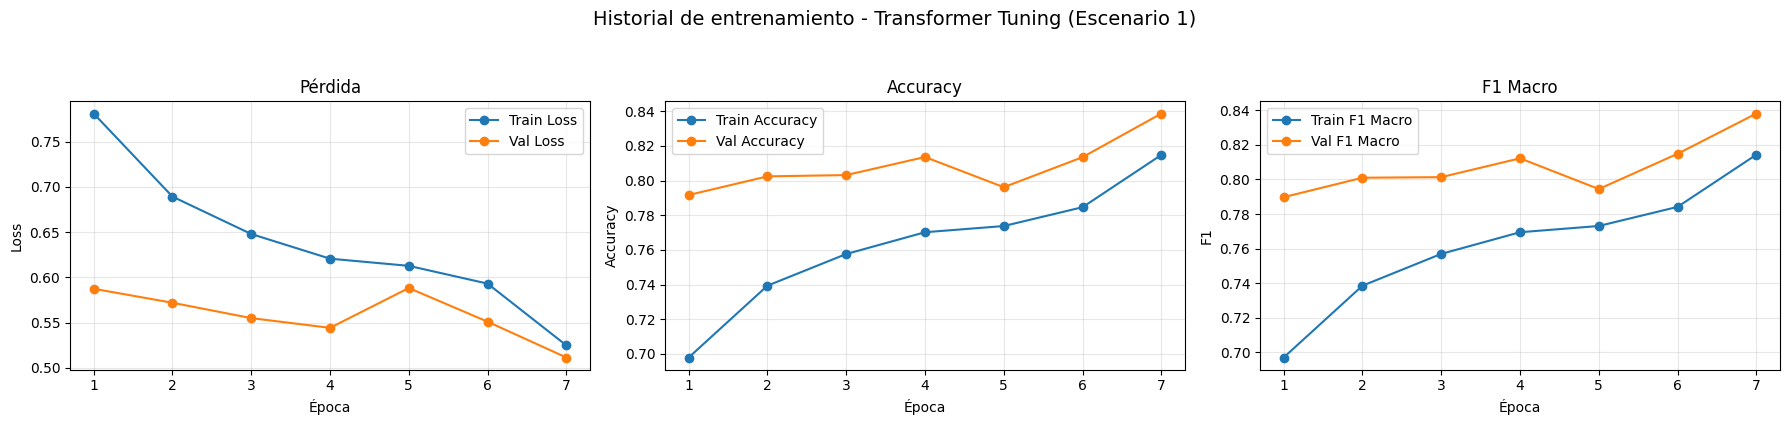

Val Loss: 0.5113
Val Accuracy: 0.8387
Val F1 Macro: 0.8381
Tiempo de entrenamiento: 605.97 segundos
Mejor configuración global actualizada.


Escenario 2/10
Configuración: {'batch_size': 16, 'embedding_dim': 256, 'ff_dim': 256, 'num_heads': 8, 'num_layers': 1}

Época 1/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

...

Mejor modelo actualizado según val_f1.

Época 7/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.


Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

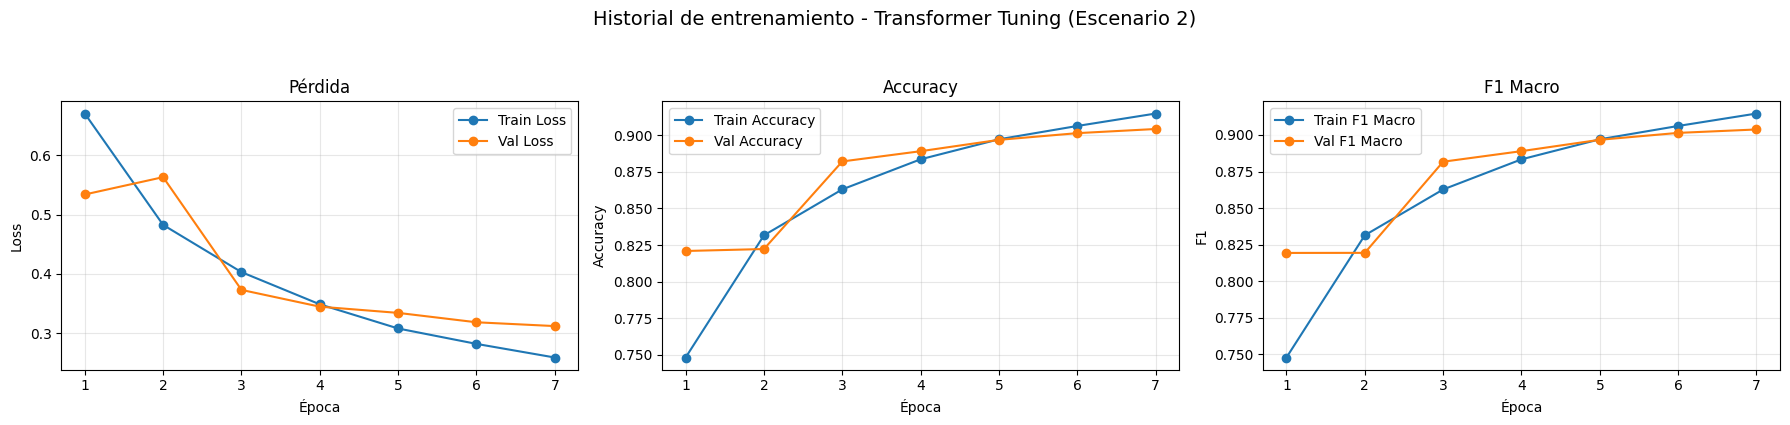

Val Loss: 0.3117
Val Accuracy: 0.9042
Val F1 Macro: 0.9038
Tiempo de entrenamiento: 490.33 segundos
Mejor configuración global actualizada.


Escenario 3/10
Configuración: {'batch_size': 32, 'embedding_dim': 128, 'ff_dim': 256, 'num_heads': 4, 'num_layers': 4}

Época 1/7


Entrenando:   0%|          | 0/3375 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/375 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/3375 [00:00<?, ?it/s]

...

Mejor modelo actualizado según val_f1.

Época 7/7


Entrenando:   0%|          | 0/3375 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/375 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.


Evaluando:   0%|          | 0/375 [00:00<?, ?it/s]

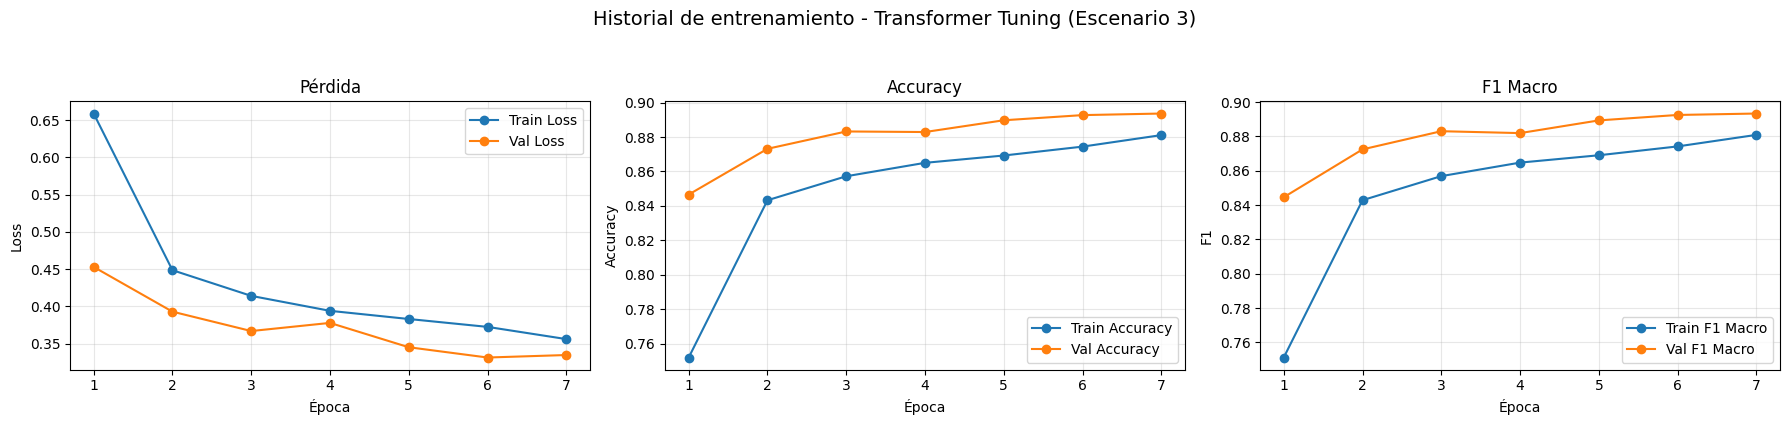

Val Loss: 0.3348
Val Accuracy: 0.8937
Val F1 Macro: 0.8933
Tiempo de entrenamiento: 426.94 segundos

Escenario 4/10
Configuración: {'batch_size': 64, 'embedding_dim': 128, 'ff_dim': 512, 'num_heads': 4, 'num_layers': 4}

Época 1/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

...


Época 7/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.


Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

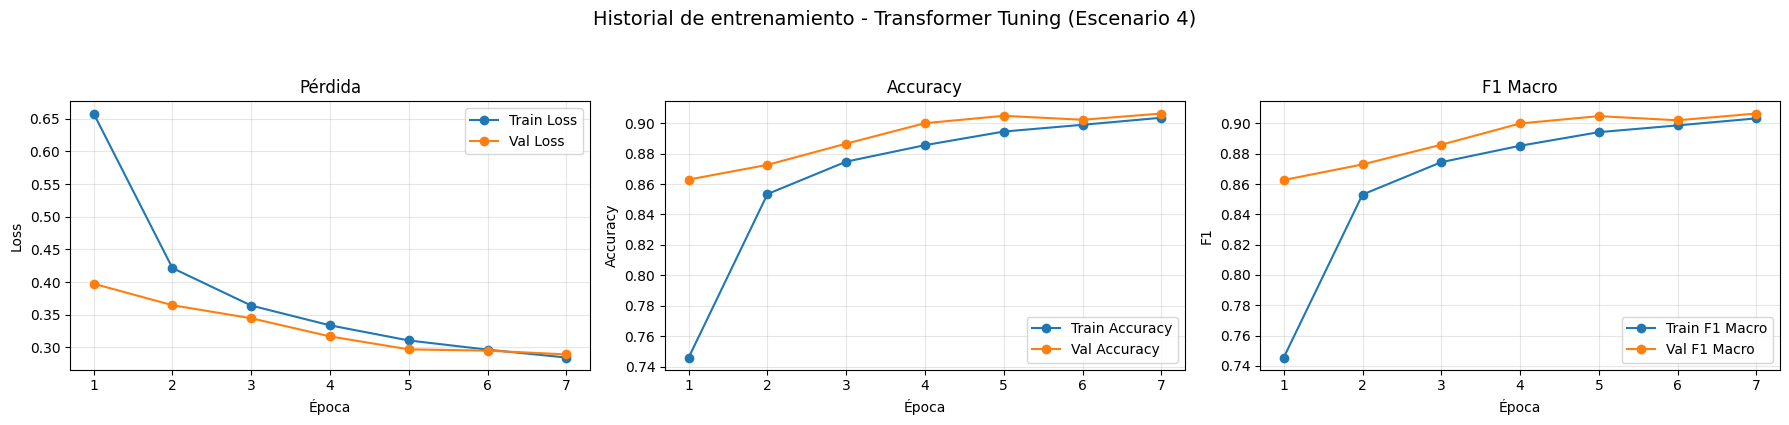

Val Loss: 0.2893
Val Accuracy: 0.9062
Val F1 Macro: 0.9065
Tiempo de entrenamiento: 375.36 segundos
Mejor configuración global actualizada.


Escenario 5/10
Configuración: {'batch_size': 64, 'embedding_dim': 256, 'ff_dim': 512, 'num_heads': 4, 'num_layers': 1}

Época 1/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

...

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]


Época 7/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

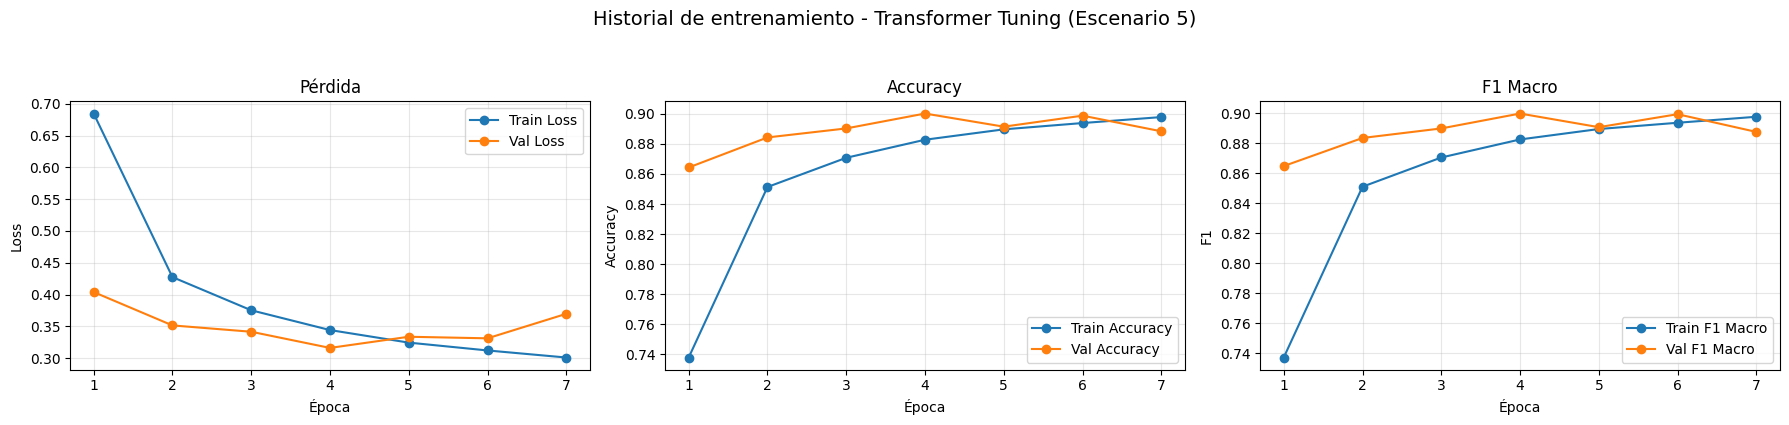

Val Loss: 0.3161
Val Accuracy: 0.9002
Val F1 Macro: 0.8999
Tiempo de entrenamiento: 240.48 segundos

Escenario 6/10
Configuración: {'batch_size': 32, 'embedding_dim': 256, 'ff_dim': 512, 'num_heads': 8, 'num_layers': 2}

Época 1/7


Entrenando:   0%|          | 0/3375 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/375 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/3375 [00:00<?, ?it/s]

...

Evaluando:   0%|          | 0/375 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 7/7


Entrenando:   0%|          | 0/3375 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/375 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/375 [00:00<?, ?it/s]

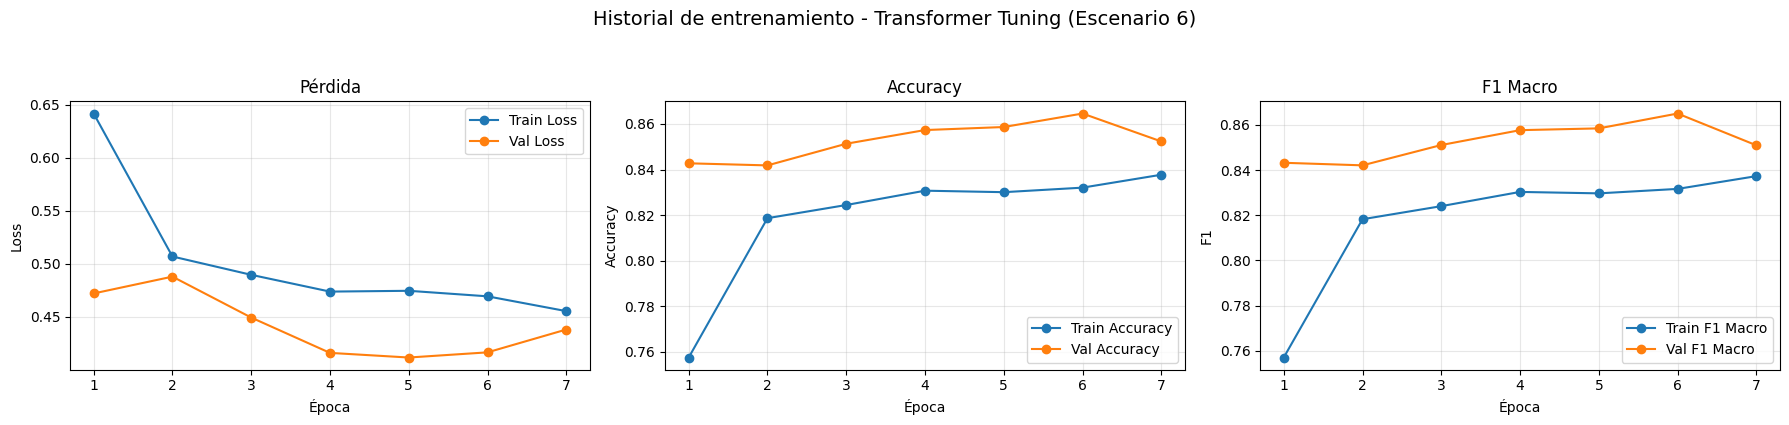

Val Loss: 0.4164
Val Accuracy: 0.8646
Val F1 Macro: 0.8650
Tiempo de entrenamiento: 510.98 segundos

Escenario 7/10
Configuración: {'batch_size': 16, 'embedding_dim': 128, 'ff_dim': 512, 'num_heads': 4, 'num_layers': 4}

Época 1/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

...


Época 7/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.


Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

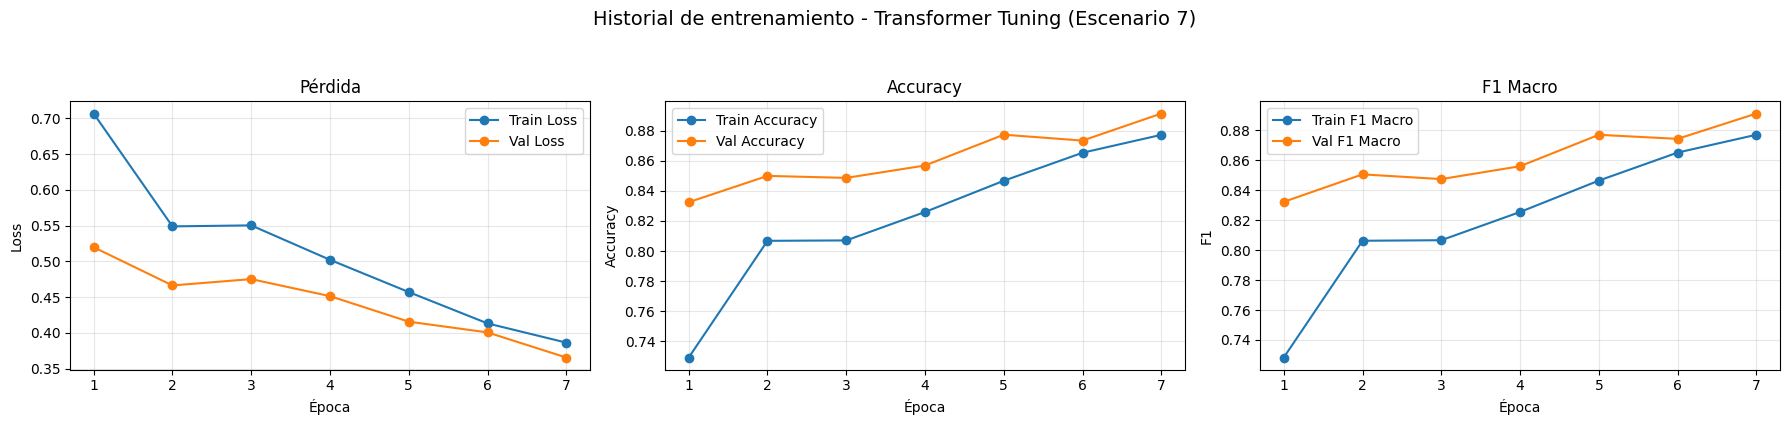

Val Loss: 0.3657
Val Accuracy: 0.8915
Val F1 Macro: 0.8912
Tiempo de entrenamiento: 876.11 segundos

Escenario 8/10
Configuración: {'batch_size': 32, 'embedding_dim': 256, 'ff_dim': 256, 'num_heads': 8, 'num_layers': 2}

Época 1/7


Entrenando:   0%|          | 0/3375 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/375 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/3375 [00:00<?, ?it/s]

...

Mejor modelo actualizado según val_f1.

Época 7/7


Entrenando:   0%|          | 0/3375 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/375 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.


Evaluando:   0%|          | 0/375 [00:00<?, ?it/s]

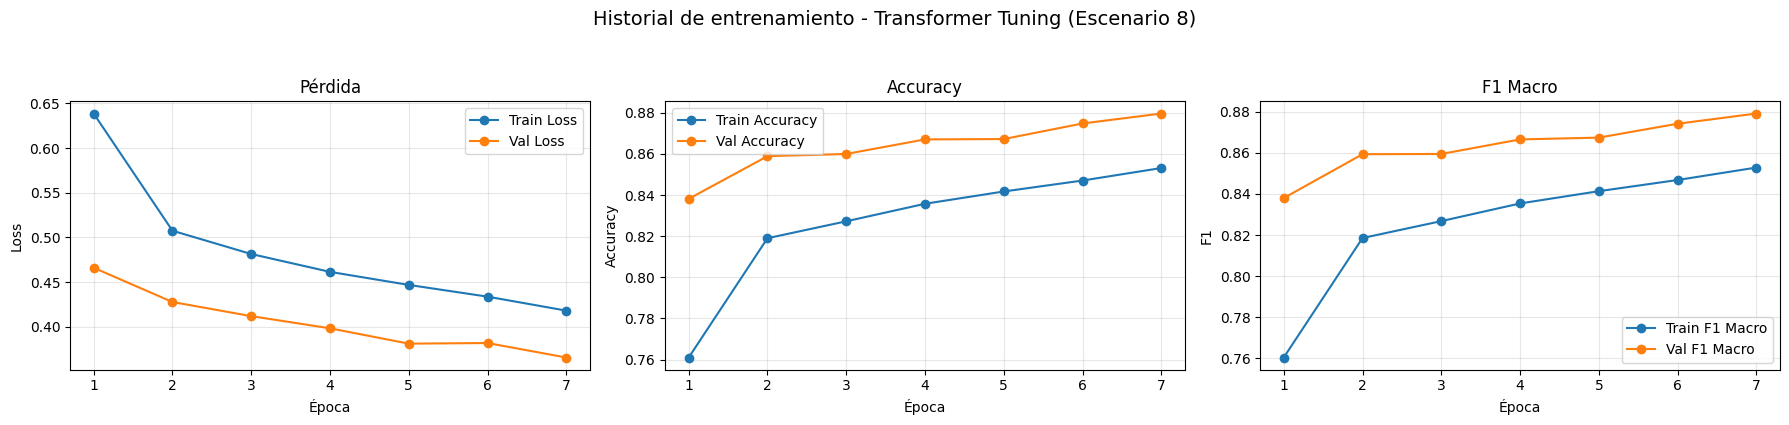

Val Loss: 0.3657
Val Accuracy: 0.8797
Val F1 Macro: 0.8791
Tiempo de entrenamiento: 449.90 segundos

Escenario 9/10
Configuración: {'batch_size': 64, 'embedding_dim': 256, 'ff_dim': 256, 'num_heads': 8, 'num_layers': 2}

Época 1/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

...

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 7/7


Entrenando:   0%|          | 0/1688 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/188 [00:00<?, ?it/s]

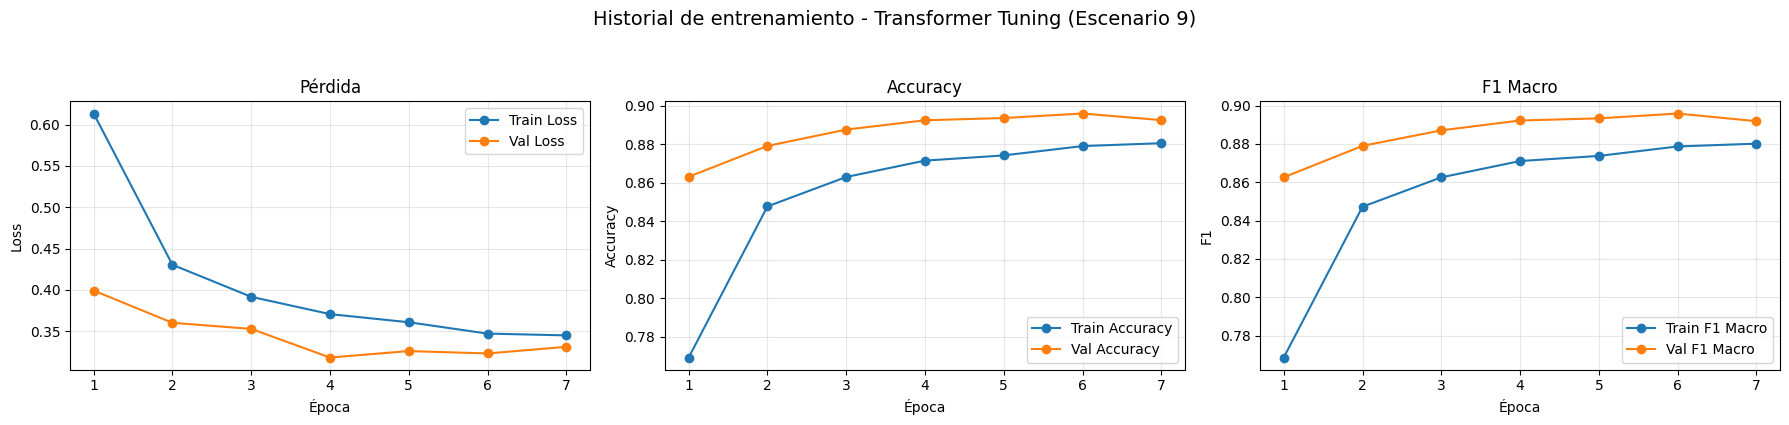

Val Loss: 0.3230
Val Accuracy: 0.8958
Val F1 Macro: 0.8959
Tiempo de entrenamiento: 348.38 segundos

Escenario 10/10
Configuración: {'batch_size': 16, 'embedding_dim': 256, 'ff_dim': 256, 'num_heads': 4, 'num_layers': 4}

Época 1/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

Mejor modelo actualizado según val_f1.

Época 2/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

...

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]


Época 7/7


Entrenando:   0%|          | 0/6750 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]

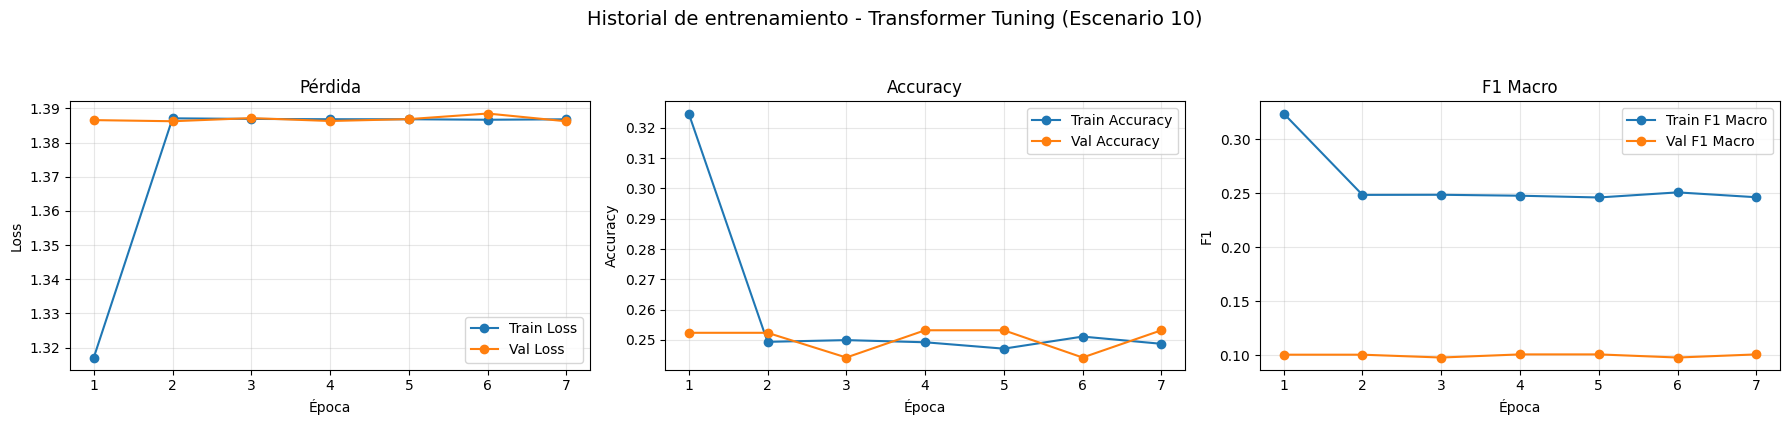

Val Loss: 1.3863
Val Accuracy: 0.2532
Val F1 Macro: 0.1010
Tiempo de entrenamiento: 959.27 segundos


In [ ]:
# Lista donde guardaremos los resultados de todos los escenarios
tuning_results = []

# Variables para conservar la mejor configuración y el mejor modelo
best_tuning_val_f1 = -float("inf")
best_tuning_config = None
best_tuning_state = None
best_tuning_history = None

# Iteramos sobre cada configuración de escenario, entrenamos el modelo y evaluamos su desempeño en validación.
for trial_idx, config in enumerate(trial_configs, start=1):
    print()
    print("=" * 100)
    print(f"Escenario {trial_idx}/{len(trial_configs)}")
    print("Configuración:", config)

    # Creamos DataLoaders según el batch_size del escenario
    train_loader_tune, val_loader_tune, test_loader_tune = create_dataloaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        batch_size=config["batch_size"],
    )

    # Instanciamos el modelo Transformer con la configuración actual
    model = TransformerClassifier(
        vocab_size=vocab_size,
        emb_dim=config["embedding_dim"],
        num_heads=config["num_heads"],
        ff_dim=config["ff_dim"],
        num_layers=config["num_layers"],
        num_classes=num_classes,
        max_len=max_length,
        dropout=fixed_params["dropout"],
        pad_idx=tokenizer.pad_token_id,
    ).to(device)

    # Definimos función de pérdida y optimizador
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=fixed_params["learning_rate"])

    # Medimos tiempo de entrenamiento
    start_time = time.time()

    history, best_state, best_val_f1 = train_model(
        model=model,
        train_loader=train_loader_tune,
        val_loader=val_loader_tune,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        num_epochs=max_epochs_tuning,
        max_norm=1.0,
        verbose=False,
    )

    elapsed_time = time.time() - start_time

    # Cargamos el mejor estado del escenario para evaluar métricas finales en validación
    model.load_state_dict(best_state)

    val_loss, val_acc, val_f1, _, _ = evaluate_model(
        model=model, dataloader=val_loader_tune, criterion=criterion, device=device
    )

    # Graficamos el historial de entrenamiento de este escenario
    plot_training_history(
        history,
        title=f"Historial de entrenamiento - Transformer Tuning (Escenario {trial_idx})",
    )

    # Guardamos resultados del escenario
    row = {
        "trial": trial_idx,
        "batch_size": config["batch_size"],
        "embedding_dim": config["embedding_dim"],
        "ff_dim": config["ff_dim"],
        "num_heads": config["num_heads"],
        "num_layers": config["num_layers"],
        "learning_rate": fixed_params["learning_rate"],
        "dropout": fixed_params["dropout"],
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_f1": val_f1,
        "train_time_sec": elapsed_time,
        "train_time_min": elapsed_time / 60.0,
    }

    tuning_results.append(row)

    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Val F1 Macro: {val_f1:.4f}")
    print(f"Tiempo de entrenamiento: {elapsed_time:.2f} segundos")

    # Actualizamos la mejor configuración global del tuning
    if val_f1 > best_tuning_val_f1:
        best_tuning_val_f1 = val_f1
        best_tuning_config = config.copy()
        best_tuning_state = best_state
        best_tuning_history = history
        print("Mejor configuración global actualizada.\n")

**Notas:**

Muy a nivel general podemos notar lo siguiente:

- En la mayoría de los escenarios se observa un comportamiento de entrenamiento estable, como observamos en la seccción anterior.

- La pérdida disminuye progresivamente mientras que la accuracy y el F1 aumentan de forma gradual, con curvas de entrenamiento y validación relativamente cercanas.

-  Muchos escenarios presentan curvas y metricas muy simialres, lo que indica que cambios en algunos hiperparámetros producen dinámicas de aprendizaje muy simialres.

- Por otro lado, hay escenarios con un comportamiento claramente distinto que sugiere una inadecuada elección de hiperparametros para la labor.

## 😔 Resultados del tuning

Los resultados de todos los escenarios evaluados se consolidan en una tabla para facilitar su revisión y comparación.

In [ ]:
# Convertimos los resultados a un DataFrame de pandas
tuning_results_df = pd.DataFrame(tuning_results)

# Ordenamos por F1 macro en validación (de mayor a menor)
tuning_results_df = tuning_results_df.sort_values(
    by="val_f1", ascending=False
).reset_index(drop=True)

# Eliminar escenarios con val_accuracy menor a 0.5
tuning_results_df = tuning_results_df[tuning_results_df["val_accuracy"] >= 0.5]

tuning_results_df

,trial,batch_size,embedding_dim,ff_dim,num_heads,num_layers,learning_rate,dropout,val_loss,val_accuracy,val_f1,train_time_sec,train_time_min
0,4,64,128,512,4,4,0.001,0.2,0.289312,0.906250,0.906526,375.363603,6.256060
1,2,16,256,256,8,1,0.001,0.2,0.311727,0.904250,0.903775,490.333304,8.172222
2,5,64,256,512,4,1,0.001,0.2,0.316102,0.900250,0.899907,240.481339,4.008022
3,9,64,256,256,8,2,0.001,0.2,0.322991,0.895833,0.895905,348.383559,5.806393
4,3,32,128,256,4,4,0.001,0.2,0.334811,0.893667,0.893326,426.937339,7.115622
5,7,16,128,512,4,4,0.001,0.2,0.365715,0.891500,0.891228,876.107926,14.601799
6,8,32,256,256,8,2,0.001,0.2,0.365729,0.879667,0.879105,449.895587,7.498260
7,6,32,256,512,8,2,0.001,0.2,0.416404,0.864583,0.864999,510.983603,8.516393
8,1,16,256,256,8,2,0.001,0.2,0.511281,0.838667,0.838136,605.965884,10.099431


In [51]:
print("Mejor configuración encontrada en el tuning:\n")
print(best_tuning_config)
print(f"\nMejor F1 macro en validación: {best_tuning_val_f1:.4f}")

Mejor configuración encontrada en el tuning:

{'batch_size': 64, 'embedding_dim': 128, 'ff_dim': 512, 'num_heads': 4, 'num_layers': 4}

Mejor F1 macro en validación: 0.9065


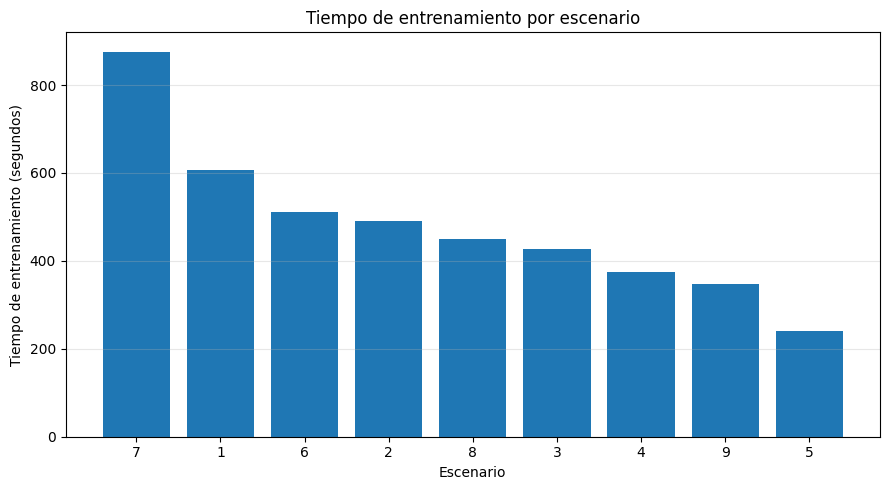

In [52]:
plot_df = tuning_results_df.sort_values("train_time_sec", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["trial"].astype(str), plot_df["train_time_sec"])
plt.xlabel("Escenario")
plt.ylabel("Tiempo de entrenamiento (segundos)")
plt.title("Tiempo de entrenamiento por escenario")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
batch_analysis = (
    tuning_results_df.groupby("batch_size")[
        ["val_accuracy", "val_f1", "train_time_sec"]
    ]
    .mean()
    .sort_values("val_f1", ascending=False)
    .round(4)
)

print("Análisis promedio por batch_size:")
display(batch_analysis)

Análisis promedio por batch_size:


,val_accuracy,val_f1,train_time_sec
batch_size,,,
64,0.9008,0.9008,321.4095
32,0.8793,0.8791,462.6055
16,0.8781,0.8777,657.4690


In [ ]:
embedding_analysis = (
    tuning_results_df.groupby("embedding_dim")[
        ["val_accuracy", "val_f1", "train_time_sec"]
    ]
    .mean()
    .sort_values("val_f1", ascending=False)
    .round(4)
)

print("Análisis promedio por embedding_dim:")
display(embedding_analysis)

Análisis promedio por embedding_dim:


,val_accuracy,val_f1,train_time_sec
embedding_dim,,,
128,0.8971,0.8970,559.4696
256,0.8805,0.8803,441.0072


In [ ]:
ff_analysis = (
    tuning_results_df.groupby("ff_dim")[["val_accuracy", "val_f1", "train_time_sec"]]
    .mean()
    .sort_values("val_f1", ascending=False)
    .round(4)
)

print("Análisis promedio por ff_dim:")
display(ff_analysis)

Análisis promedio por ff_dim:


,val_accuracy,val_f1,train_time_sec
ff_dim,,,
512,0.8906,0.8907,500.7341
256,0.8824,0.8820,464.3031


In [ ]:
ff_analysis = (
    tuning_results_df.groupby("num_layers")[
        ["val_accuracy", "val_f1", "train_time_sec"]
    ]
    .mean()
    .sort_values("val_f1", ascending=False)
    .round(4)
)

print("Análisis promedio por num_layers:")
display(ff_analysis)

Análisis promedio por num_layers:


,val_accuracy,val_f1,train_time_sec
num_layers,,,
1,0.9022,0.9018,365.4073
4,0.8971,0.8970,559.4696
2,0.8697,0.8695,478.8072


**Notas:**

Este analisis de tuneo de hiperparametros nos ha dejado diversas enseñanzas. Por ejemplo:

- En el espacio de hiperparametros que se exploró, no se identificó un escenario que  superará significativamente los resultados del modelo LSTM base de la sección anterior.
- Algunos hiperparametros como el ff_dim y el tamaño del embeding no presentan cambios significativos al variar los posibles valores que estos pueden tomar.
- **Impacto del tamaño de batch:** Los resultados promedio sugieren que los tamaños de lote más grandes tienden a ofrecer mejor desempeño y además reducen considerablemente el tiempo de entrenamiento.
- **Número de capas del encoder:** Curiosamente, el análisis promedio indica que las configuraciones más profundas no necesariamente mejoran el desempeño
- El gráfico de tiempos de entrenamiento muestra diferencias claras entre configuraciones. Algunos escenarios tardan considerablemente más sin ofrecer mejoras significativas en F1 o accuracy. Esto refuerza la idea de que, para este problema, modelos relativamente simples pueden ofrecer un equilibrio más favorable entre desempeño y eficiencia.


## Evaluación de mejor modelo en Test set

Una vez identificada la mejor configuración del tuning según el F1 macro de validación, se evalúa dicha versión del modelo sobre el conjunto de prueba. Esto permite analizar si la pequeña mejora observada durante la búsqueda de hiperparámetros también se refleja fuera del conjunto de validación.

In [45]:
# Reinstanciamos el mejor modelo Transformer encontrado en el tuning
best_transformer_tuned = TransformerClassifier(
    vocab_size=vocab_size,
    emb_dim=best_tuning_config["embedding_dim"],
    num_heads=best_tuning_config["num_heads"],
    ff_dim=best_tuning_config["ff_dim"],
    num_layers=best_tuning_config["num_layers"],
    num_classes=num_classes,
    max_len=max_length,
    dropout=fixed_params["dropout"],
    pad_idx=tokenizer.pad_token_id,
).to(device)

# Cargamos el mejor estado encontrado durante el tuning
best_transformer_tuned.load_state_dict(best_tuning_state)

# Definimos criterion para evaluación final
best_tuned_criterion = nn.CrossEntropyLoss()

# Creamos loaders con el batch_size de la mejor configuración
train_loader_best, val_loader_best, test_loader_best = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=best_tuning_config["batch_size"],
)

# Evaluación final en test
(
    best_tuned_test_loss,
    best_tuned_test_acc,
    best_tuned_test_f1,
    best_tuned_y_true,
    best_tuned_y_pred,
) = evaluate_model(
    model=best_transformer_tuned,
    dataloader=test_loader_best,
    criterion=best_tuned_criterion,
    device=device,
)

print("Resultados finales en test - Mejor Transformer ajustado")
print(f"Test Loss: {best_tuned_test_loss:.4f}")
print(f"Test Accuracy: {best_tuned_test_acc:.4f}")
print(f"Test F1 Macro: {best_tuned_test_f1:.4f}")

Evaluando:   0%|          | 0/119 [00:00<?, ?it/s]

Resultados finales en test - Mejor Transformer ajustado
Test Loss: 0.3075
Test Accuracy: 0.9045
Test F1 Macro: 0.9046


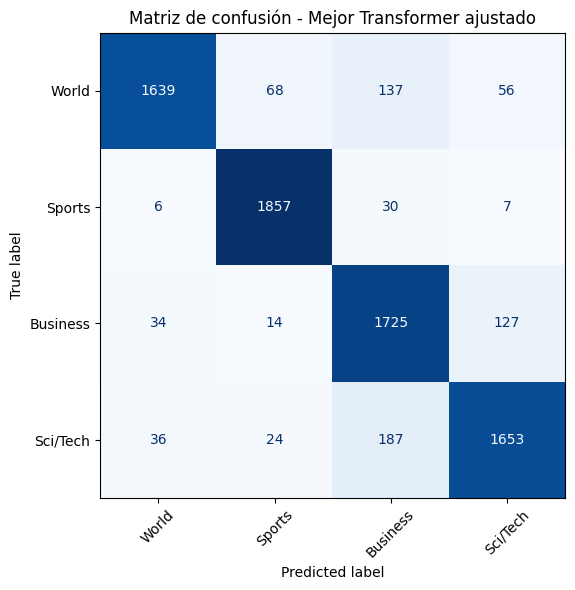


Reporte de clasificación:
              precision    recall  f1-score   support

       World     0.9557    0.8626    0.9068      1900
      Sports     0.9460    0.9774    0.9614      1900
    Business     0.8297    0.9079    0.8671      1900
    Sci/Tech     0.8969    0.8700    0.8832      1900

    accuracy                         0.9045      7600
   macro avg     0.9071    0.9045    0.9046      7600
weighted avg     0.9071    0.9045    0.9046      7600



In [46]:
plot_confusion_matrix_from_preds(
    y_true=best_tuned_y_true,
    y_pred=best_tuned_y_pred,
    class_names=class_names,
    title="Matriz de confusión - Mejor Transformer ajustado",
)

**Notas:**

A nivel general, los resultados obtenidos sobre el test set no superan los obtenidos por el modelo LSTM.

Este mejor modelo de Transformer demuestra capacidades muy competitivas a la hora de predecir noticias deportivas, pero a costa de reducir su capacidad de discriminación en otras noticias como Sci/Tech y Bussiness.

Consideramos que continuar tunenado el modelo Transformer no seria la via correcta en este caso y con este dataset, para encontrar mejores resultados de clasificación.

# 7. 🏁 Conclusiones y notas finales

**Objetivo y contexto**
----

A lo largo de este taller el objetivo no fue reconstruir por completo la arquitectura Transformer desde cero, sino adoptar un enfoque más aplicado y experimental. La idea fue construir un clasificador de noticias con módulos estándar de PyTorch, utilizando un `TransformerEncoder`, y compararlo de manera razonable frente a un modelo LSTM bajo un mismo pipeline de entrenamiento, evaluación y análisis.

A lo largo del notebook se trabajó con el dataset AG News, se realizó una exploración básica de los datos, se incorporó un tokenizador moderno de Hugging Face y se definieron dos arquitecturas comparables: un modelo LSTM como baseline secuencial y un modelo Transformer como enfoque principal del taller. Además, se implementó un proceso de tuning sencillo sobre el Transformer para explorar si algunas configuraciones de entrenamiento podían hacerlo más competitivo frente al baseline.

**Conclusión del ejercicio realizado**
----

El resultado principal del trabajo es claro: **en este contexto específico, el modelo Transformer no logró superar al modelo LSTM.** A pesar de probar distintas configuraciones de batch size, dimensión de embeddings, dimensión feedforward, learning rate y dropout, no se encontró un escenario que superara de manera consistente un F1 macro de 0.91 ni que mejorara de forma clara el comportamiento del baseline recurrente.

Esto no es necesariamente inesperado. Los Transformers suelen mostrar sus ventajas cuando se dispone de conjuntos de datos más grandes o cuando las dependencias a largo plazo dentro de las secuencias son más complejas. Con un dataset de tamaño moderado y secuencias relativamente cortas (100 tokens), un LSTM bien ajustado pudo competir muy bien.

**Posibles siguientes pasos**  
-----
Dado que entrenar un Transformer desde cero con un dataset relativamente pequeño puede limitar su desempeño, una dirección natural para siguientes pasos es utilizar modelos de lenguaje preentrenados como BERT, RoBERTa o DistilBERT. Estos modelos ya han aprendido representaciones lingüísticas generales a partir de grandes corpus de texto y pueden adaptarse a tareas específicas mediante fine-tuning sobre el dataset de clasificación de noticias.

**Aporte e innovación del taller**  
----
En términos metodológicos, consideramos que el principal aporte de este taller fue haber transformado el ejemplo pedagógico de clase en un experimento comparativo más completo. En lugar de enfocarnos solo en entender la mecánica interna del Transformer, tratamos de construir un pipeline reproducible, con tokenización moderna, separación entre train/validation/test, métricas comparables, análisis visual de entrenamiento y una exploración básica de hiperparámetros. Desde esa perspectiva, el taller no solo permitió implementar un Transformer, sino también evaluar críticamente cuándo su uso realmente aporta valor frente a un modelo más simple.
